# NB25 - all stability-leads variants side by side

Every configuration tested in the stability-leads plan, re-run in one kernel and plotted against
the shared anchor: equity curves, underwater curves, the return-versus-smoothness trade-off, and
one combined metrics table. The same view NB12 gave the previous batch.

**Based on:** the variants defined in
[21-backtest-vol-matched-family.ipynb](21-backtest-vol-matched-family.ipynb),
[22-backtest-joint-downside.ipynb](22-backtest-joint-downside.ipynb) and
[23-backtest-sortino-leg-swap.ipynb](23-backtest-sortino-leg-swap.ipynb), with the shared harness
and adoption rule v3 from [20-stability-leads-plan.md](20-stability-leads-plan.md). Full window,
2026-01-01 to 2026-09-08, in-sample throughout.

## Why this notebook exists

[24-backtest-closeout.ipynb](24-backtest-closeout.ipynb) already re-runs every configuration and
re-derives every gate, but it is an adoption document: it plots four equity curves out of
thirty-six and has no underwater comparison. Each experiment notebook, meanwhile, compares its own
family against the anchor and never against the other families. This notebook adds only the
picture. Nothing new is tested, no gate is evaluated, and it cannot change a verdict - NB24 owns
those.

## Key new insights and what did we learn from this experiment?

- **DIAGNOSTIC.** No verdict here. 35 variants plus the anchor, 0 of 36 passing all seven
  constraints (cell 24) - and the anchor is one of the thirty-six that fails, on three of them,
  which is the clearest possible demonstration that this table ranks shapes rather than deciding
  adoption.
- **The families differ in how much return they keep, not in which constraints they touch**
  (cell 38). The failure sets are nested rather than distinct: every constraint the
  data-availability drop family fails, the other two families also fail, and they add more. The
  drop family fails ulcer x7, Sharpe non-inferiority x5, beta x4 and the CAGR floor x4, and is the
  only family that never fails the volatility constraint; the eleven joint-downside runs fail all
  six substantive constraints on every single run; the twelve Sortino-swap runs fail CAGR, Sharpe
  and ulcer on every run and add beta x5 and volatility x2. What actually separates them is return
  retention: 8 of 12 drop settings clear the 20% CAGR floor and 0 of the other 23 runs do. Median
  CAGR says the same, +35.79% for the drop family against -22.51%, -14.79% and +7.91% for the
  other three. An earlier draft of this heading described the families as failing in
  "qualitatively different ways", which selected the drop family's margin failures and the other
  families' CAGR failures and read past the rest of both inventories.
- **The late-period flag separates the families, but it is close to a restatement of "did it make
  money"** (cells 26, 38). `late_ok` is the conjunction of two strict inequalities,
  `late_cagr > 0` and `late_ulcer <` the anchor's. It holds for 8 of 12 drop runs, 0 of 11 joint
  downside and window-sensitivity runs, 4 of 11 Sortino-swap runs and 0 of 1 policy run - but all
  19 failures outside the drop family fail on the FIRST leg, a negative late CAGR, which the
  median CAGR row already told us. Three further reasons not to read it as graceful degradation:
  - the anchor itself scores `late_ok = False`, because the second leg compares it strictly
    against its own value, so the flag cannot rank anything against the baseline it is defined on;
  - for near-anchor members it turns on floating-point noise. `late_ulcer_vs_anchor` (cell 26)
    shows `drop_10` clearing the ulcer leg by 1.21e-06 and `drop_20` missing it by 1.20e-04;
  - `drop_5` reproduces the anchor bit for bit on all ten panel metrics, so one of the twelve drop
    runs is the anchor under another name and scores False for the anchor's definitional reason.

  Three of the drop family's four `late_ok` failures are the ulcer leg, not the CAGR leg, so the
  8-of-12 count is genuinely measuring something different inside the drop family than it is
  measuring across families.
- **Four runs meet the strict two-axis predicate, and the margins matter more than the count**
  (cell 34): `drop_10`, `drop_15`, `drop_30` and `drop_35`, all in the drop family. Two of the four
  are wins only arithmetically - `drop_10` improves the ulcer by 0.0026% relative and the CAGR by
  7.7e-05 absolute, `drop_15` improves the ulcer by 0.33% - both far inside the 4.4% scale at which
  this notebook stops interpreting an ulcer difference. Two are real: `drop_30` at 48.99% CAGR
  against the anchor's 37.90%, ulcer 1.384% against 1.796% (-22.9%), Martin ratio 35.39 against
  21.10 and invested beta 0.0011 against 0.0458; and `drop_35` at 38.01% CAGR with ulcer 1.386%
  (-22.8%). `drop_30`'s only failed constraint in this table is the observed control, which is the
  self-comparison described next.
- **Constraint 7 fails every row including the anchor, and the comparator is not one number**
  (cells 24, 26, 38). The reference is the best observed control at or below the candidate's OWN
  volatility, so it varies by row: `c7_reference` (cell 24) shows `drop_30` setting the bar for 25
  of the 36 rows, `drop_50` for six, `drop_35` for three and `drop_60` for two. Four rows -
  `drop_30`, `drop_35`, `drop_50` and `drop_60` - are compared against themselves and so require
  `S >= S + 0.10`, a definitional impossibility, and the remaining eight drop rows are compared
  against another member of the family they themselves constitute. NB21 is right to treat
  constraint 7 as INAPPLICABLE to this family and report `passes_1_to_6` instead, and NB24 already
  records it as a pre-registered threshold that turned out badly placed. For the 23 rows where the
  constraint IS applicable it is not load-bearing either: every one of them already fails the CAGR
  floor. Read the `observed control` column as an artefact of applying the constraint uniformly,
  not as 36 informative failures.

## Summary of results

- **35 variants plus the anchor, 656 seconds of backtests, one kernel** (cell 24). Anchor parity
  holds against `BASELINE` on all ten metrics and both `decide_trades` splices are asserted inert
  (cell 20), so these curves are directly comparable to NB21-NB24's.
- **Per family** (cell 38), runs / passing all seven / late period holds / median CAGR / median
  ulcer: data-availability drop 12 / 0 / 8 / +35.79% / 1.684%; joint downside 7 / 0 / 0 / -22.51%
  / 7.620%; joint-downside window sensitivity 4 / 0 / 0 / -14.79% / 7.183%; Sortino leg swap
  11 / 0 / 4 / +7.91% / 3.566%; the strict-admission policy run 1 / 0 / 0 / +7.91% / 3.594%; the
  anchor 1 / 0 / 0 / +37.90% / 1.796%.
- **The complete failure inventory, all six groups in cell 38.** Data-availability drop: observed
  control x12, ulcer not material x7, Sharpe non-inferiority x5, beta x4, CAGR floor x4, volatility
  never. Joint downside: CAGR, Sharpe, volatility, ulcer, beta and observed control, x7 each -
  every run fails every constraint except the deployment floor. Joint-downside window sensitivity:
  the same six, x4 each. Sortino leg swap: CAGR, Sharpe, ulcer and observed control x11 each, beta
  x4, volatility x2. The policy run: CAGR, Sharpe, ulcer, beta and observed control, x1 each. The
  anchor: ulcer not material, beta, observed control. No run in any group breaches the 90%
  deployment floor and no run was disqualified for a non-finite metric.
- **The underwater chart is the plan's objective drawn directly.** The drop family's curves sit
  above the anchor's for most of the window; joint downside spends the second half far below it.
- **The Sharpe-against-volatility panel draws constraint 7 as the step function it is** (cell 36):
  the running maximum of the drop family's Sharpe plus the 0.10 margin, which by construction can
  never fall as volatility rises. The family's own profile does fall repeatedly, so it is drawn as
  points rather than as the bar - joining those points and calling the result the bar would
  understate it across the 14.9% to 15.4% band where most of the runs sit. Nothing clears the step.

## Robustness of results

- **This notebook evaluates no gate.** `passes_v3` here is constraints 1 to 7 only. Adoption also
  requires a plateau, a surviving leave-one-vault-out and the late period, and NB21 to NB24 own
  those. A row showing few failures is not close to adoption: `drop_30` fails only the definitional
  constraint here and was still REJECTED by NB21, whose plateau test found the centre passing and
  the UPPER neighbour `drop_35` passing, but the lower neighbour `drop_25` failing constraint 4
  (ulcer not material). A 5-step plateau needs both neighbours, so one is enough to reject.
- **Nothing here cross-checks NB21 to NB24.** This notebook re-runs 35 configurations those
  notebooks already ran, but it asserts parity only against the anchor (cell 20), never against
  their frozen results. The independent review of this notebook checked all 35 externally against
  `_build/manifest_24.json` and every metric agrees exactly, so there is no discrepancy to report -
  but the notebook does not establish that itself, and on a future data snapshot a divergence would
  go unnoticed. The check belongs in the notebook.
- **Two pairs of rows are identical, not merely similar.** `drop_5` reproduces the anchor on all
  ten panel metrics to the last bit, so at N = 5 the removals never changed the basket and the
  family's first member is the anchor under another name; every "N of 12" above counts it.
  `swap__centre` and `swap__require_scored` are likewise identical, so `require_scored_candidates`
  changes nothing on this snapshot. Both overlaps are invisible in the charts, where one curve sits
  exactly under the other.
- **The family is renamed, deliberately.** It is labelled "data-availability drop", not
  "volatility drop", because NB21 measured that 70.9% of its removals at N = 30 are vaults with no
  volatility estimate at all, and 57.91% pooled across all settings are young, unmeasured and
  unscored. Carrying the old name into a chart legend would relabel that finding out of existence.
- **The underwater sensitivity is context, not an error bar.** NB20 found that dropping the eleven
  cycles where a majority of the invested book sat inside a five-day stale window moves the
  ANCHOR's ulcer by 4.4%. It was measured on the anchor alone and never measured a
  candidate-minus-anchor difference, so it is neither an error bar on any curve here nor a
  distinguishability threshold between two curves. Its honest use is as a rough sense of scale: a
  gap of that order between two of these curves is small enough that reporting behaviour remains a
  live alternative explanation for it.
- **Nothing here is out of sample.** Every configuration was chosen after seeing results on this
  window, and the family-wise test in NB24 returns p = 0.813 over the complete 35-run family, which
  reflects a test with almost no power rather than an established absence of effect.
- The table's `martin` ranking is retained for continuity with NB12 and the earlier track. It is
  not part of adoption rule v3 and no decision in this plan rests on it.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean single backtest.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as the parent notebook so the accounting comparison is direct.


In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- The parent configuration is unchanged except for redemption accounting.
- Each redemption charges a 10% fee on positive profit and 10 bps of gross redeemed capital.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '25-research-stability-comparison'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    #: **NB92 winner.** NB92's recommendation and an interior optimum confirmed from both sides: mean CAGR
    #: 5 -> 20.82%, 6 -> 21.89%, 7 -> 15.27%, 8 -> 15.60%. Opening the range down to 5 confirmed 6
    #: rather than moving the optimum.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 45
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    #: **NB92 winner.** NB92's recommendation, and a value no earlier search in this chain contained - NB90 ran
    #: 0.3/0.5/0.7 and settled on 0.5, stepping straight over the optimum. All 15 of NB92's top
    #: configurations use 0.6, at 100% consensus.
    #:
    #: This is the top of NB92's range and 0.7 was dropped from it on a marginal mean measured
    #: under different companion values, so whether 0.7 is better is still open.
    cagr_weight = 0.60
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    #: **NB92 winner.** Unchanged. NB92 confirmed this axis is inert across a range 50% wider than NB90's: mean CAGR
    #: spans only 17.52% to 19.54% across all six searched values, and the two newly opened
    #: permissive values changed nothing.
    gate_threshold = -0.16
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    #: **NB92 winner.** NB92's recommendation and a genuine interior optimum: mean CAGR 60 -> 18.44%, 75 -> 19.93%,
    #: 90 -> 21.03%, 105 -> 16.04%. The collapse at 105 is what makes 90 interior rather than a
    #: boundary artefact.
    #:
    #: Chosen over the higher-scoring window-60 configurations deliberately. Those returned up to
    #: 34.12% but their worst one-step neighbour falls to 11-12%, because 60 is a boundary and the
    #: step off it lands on the sharpe_lookback_days cliff. At 90 the worst neighbour holds at
    #: 31.69%.
    inverse_vol_window = 90

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: Sizing rule, searched rather than pinned. NB71 and NB72 showed the ranking between these two
    #: **reverses with the concentration cap** - inverse variance wins at 33% and loses at 25% - so
    #: it cannot be assumed to carry over to a different selection score. NB77 gives a further
    #: reason to re-test it here: inverse variance weights by the reciprocal of variance, so it
    #: hands the largest positions to the low-volatility cohort that loses most often.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary. Extended to "yesterday" for the lower-vol track baseline;
    #: vault price history is now pulled fresh from the Trading Strategy website each run.
    #: Exclusive end boundary, so the last traded day is 2026-09-08 - the same full window
    #: as 01-initial.ipynb and 02-better-format.ipynb.
    #:
    #: This track originally ran on a 2026-01-01 to 2026-06-30 development window with
    #: 2026-07-01 to 2026-09-08 reserved as a hold-out. That split has been retired: every
    #: notebook now runs the full window. The consequence is that results are in-sample
    #: throughout and the track no longer carries an out-of-sample claim.
    backtest_end = datetime.datetime(2026, 9, 9)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Margin withheld by the same-cycle buy cap. Sell proceeds are sized at
    #: mark-to-market value but execute slightly lower due to redemption fees,
    #: price movement, and raw-unit rounding.
    sync_cash_headroom_usd = max(0.50, initial_cash * 0.0005)

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Performance fee charged only on positive profit at redemption.
    vault_performance_fee = 0.10
    #: Fixed capital fee charged on every redemption, including loss-making redemptions.
    vault_redemption_capital_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01

    #: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
    #: Rolling window for `btc_beta` / `btc_beta_r2`.
    beta_window_days = 90
    #: Rolling window for `fresh_observation_count`.
    fresh_window_days = 90
    #: Minimum fresh (non-zero-return) observations before a staleness-sensitive statistic is trusted.
    min_fresh_observations = 60
    #: Window for `ulcer_index_180`.
    ulcer_window_days = 180
    #: Window for `downside_deviation_90`.
    downside_window_days = 90
    #: Rolling-return window and lookback span for `positive_window_share`.
    consistency_window_days = 30
    consistency_span_days = 180
    #: Window for `residual_event_concentration`.
    event_window_days = 180
    #: Window for `gain_to_pain_score`.
    gain_to_pain_window_days = 180
    #: NB04: target annualised portfolio volatility. None disables vol targeting (anchor behaviour).
    target_portfolio_vol = None
    #: NB07: which per-vault risk indicator sizes the basket when `weighting_method` is
    #: `inverse_ulcer` or `inverse_downside`.
    sizing_risk_indicator = 'inverse_vol'
    #: NB07: floor on any sizing weight as a fraction of the mean weight, so a vault whose risk
    #: measure reads as near-zero (often because its marks are stale) cannot swallow the basket.
    weight_floor_fraction = 0.25
    #: NB07: maximum combined weight share for vaults with |btc_beta| above `beta_high_threshold`.
    #: None disables the group cap (anchor behaviour).
    high_beta_group_cap = None
    beta_high_threshold = 0.6
    #: NB08: multiply the composite by `1 - lambda * clip(residual_event_concentration, 0, 1)`.
    event_concentration_lambda = 0.0
    #: NB08: blend weight for the gain-to-pain tiebreak, `0` disables it (anchor behaviour).
    gain_to_pain_tilt = 0.0
    #: NB09: if True, a vault with a NaN composite is dropped from candidates instead of scored 0.
    require_scored_candidates = False
    #: NB07 (plan item): equal-risk-contribution sizing accounts for how correlated the selected
    #: vaults are, not just how volatile each one is. Vaults whose mean absolute correlation to the
    #: rest of the basket exceeds this cap are shrunk further.
    residual_correlation_cap = 0.60
    #: NB09 control: drop this many of the highest-volatility candidates each cycle before ranking.
    #: The pre-registered vol-matched placebo (NB42's control): if dropping names purely by
    #: volatility reproduces a selection change's risk reduction, that change is generic
    #: de-risking rather than selection skill. `0` disables it (anchor behaviour).
    vol_matched_drop_count = 0
    #: NB10: shrink `btc_beta` toward zero before building the residual CAGR leg (estimation-noise
    #: control). `1.0` is full beta (anchor behaviour for the residual variant).
    beta_shrink = 1.0

    #: --- evidence-weighted selection track additions (see 14-evidence-weighted-plan.md) ---
    #: Calendar-day window the CAGR leg (`expanding_cagr_score`) looks back over. Unlike the
    #: Sortino leg below, this is deliberately calendar-time, not event-time: a return level is
    #: well-defined between two calendar dates regardless of how many stale marks sit between them.
    evidence_max_window_days = 365
    #: Event-count window (not calendar days) the Sortino evidence statistics look back over.
    evidence_max_events = 90
    #: Fewest fresh (mark actually moved, NB57) events before an evidence statistic exists at all.
    evidence_min_events = 20
    #: Fewest of those fresh events that must be down-events, so downside deviation is not
    #: estimated from one or two observed losses.
    evidence_min_down_events = 5
    #: Shrinkage prior strength `k` in `n_eff / (n_eff + k)`. A vault needs `n_eff` well past this
    #: before its own evidence dominates the cross-sectional prior. Plateau-tested at 30, 90.
    evidence_prior_strength = 60
    #: t-equivalent that earns the full [0, 1] evidence sub-score after shrinkage. Plateau-tested
    #: at 2, 4.
    evidence_t_cap = 3.0
    #: Fresh observations at which the expanding CAGR leg is trusted in full; below this it is
    #: shrunk linearly towards zero. Plateau-tested at 90, 270.
    cagr_full_evidence_days = 180
    #: Shortest history the expanding CAGR leg is computed on at all.
    cagr_min_days = 90
    #: `inverse_vol_early` becomes available after this many FRESH observations (not calendar
    #: days). At 90 - the same value as `inverse_vol_window` - it cannot fire before `inverse_vol`
    #: itself does (see the docstring on `inverse_vol_early`), so the anchor is unchanged; NB16
    #: lowers it to 45 so a young vault that wins a slot can be sized (NB13's second barrier).
    inverse_vol_min_periods = 90
    #: NB16 objective (review 3c): Sharpe non-inferiority tolerance against the anchor, and the
    #: minimum RELATIVE ulcer-index improvement required. Both pre-registered; see harness_evidence.py.
    sharpe_noninferiority_tol = 0.10
    ulcer_improvement_frac = 0.15
    #: NB18 two-sleeve structure. None disables it (anchor behaviour). Otherwise the share of the
    #: deployed book given to the evidence-selected core sleeve. Must be in (0, 1].
    core_fraction = None
    #: NB18: number of names in the core sleeve; the satellite gets the remainder of
    #: `max_assets_in_portfolio`. Must be in [1, max_assets_in_portfolio].
    core_assets = 4
    #: NB18: indicator that ranks and sizes the core sleeve.
    core_score_indicator = 'sortino_shrunk_score'

    #: --- stability-leads track additions (see 20-stability-leads-plan.md) ---
    #: NB22. 0 disables complementary selection entirely (anchor behaviour). Otherwise the number
    #: of top-ranked candidates by composite score that the joint-loss screen chooses from; the
    #: basket size itself stays `max_assets_in_portfolio`.
    complementary_pool_size = 0
    #: NB22. Calendar window `joint_loss_frequency` measures co-movement over.
    joint_loss_window_days = 180
    #: NB22. Fewest cohort-down days inside that window on which THIS vault also reported, before
    #: a joint-loss frequency exists at all. Below this the vault has no estimate and is NOT
    #: assumed to be complementary.
    joint_loss_min_events = 10
    #: NB22. Fewest vaults that must have posted a FRESH mark on a day before that day's
    #: cross-sectional median is meaningful enough to call the cohort up or down.
    cohort_min_reporting = 5


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-09-09 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
beta_high_threshold,0.6,float
beta_shrink,1.0,float
beta_window_days,90,int
cagr_full_evidence_days,180,int


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

# Vault price history is downloaded fresh from the Trading Strategy website into the standard
# Trading Strategy cache (`~/.cache/tradingstrategy`) rather than copied from a machine-specific
# frozen archive. `load_partial_data(..., vault_history_download_root=None)` resolves the cache
# path from the oracle client, so no custom cache directory is needed.


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_capital_fee(universe, fee) -> int:
    """Set the fixed redemption-capital fee on every vault pair.

    The performance-fee component is position-specific and changes with the
    position's remaining cost basis. It is refreshed immediately before each
    portfolio decision in :func:`refresh_vault_redemption_accounting`.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_capital_fee(
    strategy_universe,
    Parameters.vault_redemption_capital_fee,
)
print(
    f'Applied a {Parameters.vault_redemption_capital_fee * 10_000:.0f} BPS '
    f'capital fee to {fee_applied} vault pairs; performance fees are refreshed per position.'
)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: bbf10d84
Loaded 339 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-curbbf10d84)


Loaded 339 vaults from remote vault metadata, source vaults count: 339


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 348.42it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.93,2026-01-21 00:00:00,5 days 00:00:00,0.00,"17,972",4 days,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.34,2026-01-14 00:00:00,5 days 00:00:00,0.00,"14,361",4 days,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,4 days,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.96,2025-01-01 00:00:00,5 days 00:00:00,0.00,"65,892",4 days,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,1.07,2026-01-27 00:00:00,5 days 00:00:00,0.00,"27,197",4 days,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.60,2025-11-19 00:00:00,5 days 00:00:00,0.00,"12,266",4 days,- / -,None,None,-,10.0%,0.0%
269792829,DH-Funding,USDC,hyperliquid,traded,NaN,0.87,2025-05-28 00:00:00,5 days 00:00:00,0.00,"6,248",4 days,- / -,None,None,-,10.0%,0.0%
271101545,DOEZOE,USDC,hyperliquid,traded,NaN,2.31,2025-06-04 00:00:00,5 days 00:00:00,0.00,"41,035",4 days,- / -,None,None,-,10.0%,0.0%
278620567,DailyTrade,USDC,hyperliquid,traded,NaN,0.12,2024-08-14 00:00:00,5 days 00:00:00,0.00,"91,421",4 days,- / -,None,None,-,10.0%,0.0%
280434712,DaoScience,USDC,hyperliquid,traded,NaN,0.19,2026-02-21 00:00:00,5 days 00:00:00,0.00,"2,250",4 days,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS capital fee to 339 vault pairs; performance fees are refreshed per position.


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


#: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
import numpy as np
from pathlib import Path
from tradingstrategy.binance.price import fetch_binance_price

#: `fetch_binance_price()` opens an exclusive-lock DuckDB connection, which several indicator
#: worker processes calling it concurrently deadlock on. Fetch once here, in the main kernel
#: process, and cache to a plain Parquet file that worker processes can read concurrently
#: without locking (per CLAUDE.md: always source BTC/Binance prices via `fetch_binance_price()`,
#: never via ad hoc HTTP calls - this still does that, just once, and hands the result to workers
#: through a file instead of a second DuckDB connection).
_BTC_DAILY_RETURNS_CACHE_PATH = Path("/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet")
if not _BTC_DAILY_RETURNS_CACHE_PATH.exists():
    _btc_close = fetch_binance_price()["close"]
    _btc_close.index = pd.to_datetime(_btc_close.index)
    if _btc_close.index.tz is not None:
        _btc_close.index = _btc_close.index.tz_localize(None)
    _btc_close.pct_change().rename("btc_daily_return").to_frame().to_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)

_BTC_DAILY_RETURNS_CACHE: dict[int, pd.Series] = {}


def _btc_daily_returns_for(index: pd.DatetimeIndex) -> pd.Series:
    """BTC daily returns aligned to `index`, cached per-process by index length.

    Reads the Parquet cache written above rather than calling `fetch_binance_price()` again, so
    that concurrent indicator worker processes never open a second DuckDB connection.
    """
    key = len(index)
    if key not in _BTC_DAILY_RETURNS_CACHE:
        series = pd.read_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)["btc_daily_return"]
        _BTC_DAILY_RETURNS_CACHE[key] = series
    return _BTC_DAILY_RETURNS_CACHE[key].reindex(index).fillna(0.0)


@indicators.define()
def fresh_observation_count(close: pd.Series, fresh_window_days: int = 90) -> pd.Series:
    """Number of days in the trailing window on which the mark actually moved.

    NB57: a zero daily return on a Hyperliquid vault is almost always a stale poll, not a flat
    day. Any statistic that needs a distribution (downside deviation, ulcer, event concentration)
    is only trusted once this count clears `Parameters.min_fresh_observations`.
    """
    moved = (close.pct_change().abs() > 0).astype(float)
    return moved.rolling(int(fresh_window_days), min_periods=1).sum()


@indicators.define()
def btc_beta(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """Rolling OLS beta of the vault's daily return on BTC's daily return."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    cov = r.rolling(w, min_periods=w).cov(b)
    var = b.rolling(w, min_periods=w).var()
    return cov / var.replace(0.0, float('nan'))


@indicators.define()
def btc_beta_r2(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """R-squared of the same regression, so a beta of 1.0 on noise is not mistaken for exposure."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    return r.rolling(w, min_periods=w).corr(b) ** 2


@indicators.define()
def ulcer_index_180(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Root-mean-square drawdown from the trailing-window high. Penalises time under water."""
    w = int(ulcer_window_days)
    drawdown = close / close.rolling(w, min_periods=w).max() - 1.0
    return (drawdown ** 2).rolling(w, min_periods=w).mean() ** 0.5


@indicators.define()
def downside_deviation_90(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Root-mean-square of negative daily returns over the trailing window."""
    r = close.pct_change()
    w = int(downside_window_days)
    return ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5


@indicators.define()
def positive_window_share(
    close: pd.Series,
    consistency_window_days: int = 30,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Share of trailing rolling 30-day returns that were positive over the trailing span."""
    rolling_return = close / close.shift(int(consistency_window_days)) - 1.0
    return (rolling_return > 0).astype(float).rolling(
        int(consistency_span_days), min_periods=int(consistency_span_days)
    ).mean()


@indicators.define()
def residual_event_concentration(
    close: pd.Series,
    event_window_days: int = 180,
    beta_window_days: int = 90,
    min_fresh_observations: int = 60,
) -> pd.Series:
    """Share of the trailing window's positive residual log return delivered by its best 5 days.

    Residual means after removing `beta * r_btc`, so a vault that is simply levered BTC does not
    look concentrated merely because BTC had a good week. The denominator is the sum of positive
    residual days, keeping the ratio in [0, 1] and defined even when total return is negative.
    NaN until `min_fresh_observations` marks have actually moved.
    """
    w = int(event_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    bw = int(beta_window_days)
    beta = r.rolling(bw, min_periods=bw).cov(b) / b.rolling(bw, min_periods=bw).var().replace(0.0, float('nan'))
    residual = np.log1p((r - beta * b).clip(lower=-0.99))
    positive = residual.clip(lower=0.0)
    top5 = residual.rolling(w, min_periods=w).apply(lambda x: np.sort(x)[-5:].sum(), raw=True)
    concentration = top5 / positive.rolling(w, min_periods=w).sum().replace(0.0, float('nan'))
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    return concentration.where(fresh >= int(min_fresh_observations))


@indicators.define()
def min_window_sortino(close: pd.Series) -> pd.Series:
    """Minimum of the bounded Sortino score across 30, 90, 180 and 360 days.

    Strict: NaN if any window lacks history, so a young vault is unscored rather than scored on
    the windows it has (the NB78 NaN-tolerant failure this must not repeat).
    """
    legs = []
    for w in (30, 90, 180, 360):
        r = close.pct_change()
        mean = r.rolling(w, min_periods=w).mean()
        downside = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
        sortino = (mean / downside.replace(0.0, float('nan'))) * (TRADING_DAYS_PER_YEAR ** 0.5)
        legs.append((sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0))
    return pd.concat(legs, axis=1).min(axis=1, skipna=False)


@indicators.define()
def residual_cagr_score(
    close: pd.Series,
    cagr_lookback_days: int = 360,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """`cagr_score` computed on a BTC-residual NAV index instead of the raw share price."""
    r = close.pct_change().fillna(0.0)
    b = _btc_daily_returns_for(r.index)
    w = int(beta_window_days)
    beta = (r.rolling(w, min_periods=w).cov(b) / b.rolling(w, min_periods=w).var().replace(0.0, float('nan'))).fillna(0.0)
    beta = beta * float(beta_shrink)
    residual_nav = (1.0 + (r - beta * b).clip(lower=-0.99)).cumprod()
    lookback = int(cagr_lookback_days)
    cagr = (residual_nav / residual_nav.shift(lookback)).pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def gain_to_pain_score(close: pd.Series, gain_to_pain_window_days: int = 180) -> pd.Series:
    """Sum of returns over sum of absolute losses, mapped 0..3 to 0..1 like the Sharpe score."""
    r = close.pct_change()
    w = int(gain_to_pain_window_days)
    gains = r.rolling(w, min_periods=w).sum()
    pain = r.clip(upper=0.0).abs().rolling(w, min_periods=w).sum()
    return ((gains / pain.replace(0.0, float('nan'))) / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, min_window_sortino),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_min_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x min-across-windows Sortino` (NB09)."""
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('min_window_sortino', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


#: Annualised downside deviation at or above this level scores 0; zero downside scores 1.
DOWNSIDE_SCORE_CAP = 1.0


@indicators.define()
def downside_score(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Bounded [0, 1] score that rewards *low* downside deviation.

    `downside_deviation_90` is a risk measure where lower is better, so it cannot be blended into
    the composite directly - the composite's other legs are all higher-is-better scores bounded to
    [0, 1]. This inverts and bounds it on the same scale.
    """
    r = close.pct_change()
    w = int(downside_window_days)
    dd = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
    annualised = dd * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (1.0 - (annualised / DOWNSIDE_SCORE_CAP)).clip(lower=0.0, upper=1.0)


@indicators.define()
def drawdown_recovery_days(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Days since the vault last set a trailing-window high - how long it stays under water.

    NB57 Stage C listed recovery speed as a feature the chain had never tested. A vault that
    grinds back to its high quickly is steadier than one that sits under water for months, and
    unlike Sharpe this is not flattered by a stale mark that simply fails to print a new low.
    """
    w = int(ulcer_window_days)
    rolling_max = close.rolling(w, min_periods=1).max()
    at_high = close >= rolling_max
    days = []
    since = 0
    for flag in at_high.to_numpy():
        since = 0 if flag else since + 1
        days.append(float(since))
    return pd.Series(days, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_per_pair)
def tvl_growth(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Trailing TVL growth: outside money arriving is independent of the share-price series.

    NB57 Stage C's argument for these features is that they do not inherit NAV staleness. NB44
    and NB50 rejected *flow* as a selection signal, but TVL trajectory as a quality proxy - rather
    than a contrarian penalty - has not been tested.
    """
    series = dependency_resolver.get_indicator_data("tvl", pair=pair)
    if series is None or len(series) == 0:
        return pd.Series(dtype="float64")
    daily = series.resample("1D").last().ffill()
    return daily / daily.shift(int(consistency_span_days)) - 1.0


@indicators.define(
    dependencies=(cagr_score, downside_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_downside_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    downside_window_days: int = 90,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x downside score` (NB09).

    Added after the NB03b screen was re-run at live parity: `downside_deviation_90` clears the
    precision-at-6 gate once the one-bar look-ahead is removed, so it earns a selection backtest
    that the original (look-ahead-contaminated) screen denied it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    downside_component = dependency_resolver.get_indicator_data(
        "downside_score", pair=pair, parameters={"downside_window_days": downside_window_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * downside_component


@indicators.define(
    dependencies=(cagr_score, positive_window_share),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_positive_window_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x share of positive rolling 30d windows` (NB09).

    `positive_window_share` cleared the NB03b precision-at-6 gate with the largest margin of any
    feature tested, so it is tried as a second consistency leg alongside `cagr_min_sortino_weight`
    rather than assumed inferior to it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('positive_window_share', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


@indicators.define(
    dependencies=(residual_cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def residual_cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    sharpe_lookback_days: int = 45,
    cagr_weight: float = 0.6,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """NB10: replace the raw-price CAGR leg of the composite with a BTC-residual CAGR leg."""
    residual = dependency_resolver.get_indicator_data(
        'residual_cagr_score', pair=pair,
        parameters={'cagr_lookback_days': cagr_lookback_days, 'beta_window_days': beta_window_days, 'beta_shrink': beta_shrink},
    )
    sortino = dependency_resolver.get_indicator_data(
        'sortino_score', pair=pair, parameters={'sharpe_lookback_days': sharpe_lookback_days},
    )
    return cagr_weight * residual + (1.0 - cagr_weight) * sortino


#: --- evidence-weighted selection track additions (see 14-evidence-weighted-plan.md) ---


def _event_time_stats(
    close: pd.Series,
    max_events: int,
    min_events: int,
    min_down_events: int,
) -> tuple[pd.Series, pd.Series]:
    """Event-time mean/downside Sortino input and an autocorrelation-discounted effective n.

    NB57: a zero daily return on a Hyperliquid vault mark is almost always a stale poll, not a
    real flat day. This restricts every calculation to the subsequence of days the mark actually
    moved (`fresh_r`), a non-contiguous slice of the calendar index, and rolls over that
    subsequence by EVENT COUNT rather than by calendar day - so the sample used for the mean and
    the downside deviation is exactly the sample counted as `n`. Draft 1's `sortino_t` counted
    fresh events as `n` but computed the mean and downside deviation over calendar rows including
    the stale (zero-return) ones between them, which understates `n` relative to the sample the
    ratio was actually estimated from (review finding #1).

    The lag-1 autocorrelation of the fresh-event series further discounts `n` via
    `n_eff = n / (1 + 2*|rho_1|)`, a truncated Newey-West-style correction: a short, smooth run -
    the shape of a pump before it reverses - produces serially correlated fresh-event returns,
    and should not be treated as that many independent observations.

    Both outputs are reindexed back onto the full calendar index, carrying the last known event
    forward, so `decide_trades` (which reads one calendar bar back, per NB57) always sees the most
    recent evidence rather than NaN on the many stale calendar days between events.
    """
    r = close.pct_change()
    fresh_r = r[r.abs() > 0]
    if len(fresh_r) == 0:
        empty = pd.Series(float('nan'), index=close.index)
        return empty, empty.copy()

    w, min_ev = int(max_events), int(min_events)
    mean_event = fresh_r.rolling(w, min_periods=min_ev).mean()
    downside_event = (fresh_r.clip(upper=0.0) ** 2).rolling(w, min_periods=min_ev).mean() ** 0.5
    down_count = (fresh_r < 0).rolling(w, min_periods=1).sum()
    n_event = fresh_r.rolling(w, min_periods=min_ev).count()

    def _autocorr1(values):
        if len(values) < 5 or np.std(values) == 0:
            return 0.0
        a, b = values[:-1], values[1:]
        if np.std(a) == 0 or np.std(b) == 0:
            return 0.0
        return float(np.corrcoef(a, b)[0, 1])

    rho1 = fresh_r.rolling(w, min_periods=min_ev).apply(_autocorr1, raw=True).fillna(0.0).clip(-0.9, 0.9)
    n_eff = n_event / (1.0 + 2.0 * rho1.abs())

    raw_sortino = (mean_event / downside_event.replace(0.0, float('nan'))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    raw_sortino = raw_sortino.where(down_count >= int(min_down_events))

    full_index = close.index
    return raw_sortino.reindex(full_index).ffill(), n_eff.reindex(full_index).ffill()


@indicators.define()
def sortino_raw_event(
    close: pd.Series,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Event-time annualised Sortino ratio; NaN until the minimum event counts are met."""
    raw, _ = _event_time_stats(close, evidence_max_events, evidence_min_events, evidence_min_down_events)
    return raw


@indicators.define()
def sortino_neff_event(
    close: pd.Series,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Autocorrelation-discounted effective observation count behind `sortino_raw_event`."""
    _, neff = _event_time_stats(close, evidence_max_events, evidence_min_events, evidence_min_down_events)
    return neff


@indicators.define(dependencies=(sortino_raw_event,), source=IndicatorSource.dependencies_only_universe)
def sortino_cross_sectional_prior(
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Cross-sectional median of `sortino_raw_event` across all vaults, per timestamp.

    Same construction as `tvl_inclusion_criteria` (`cell10_enhanced.py`): pull every pair's value
    for this indicator combined into one MultiIndex series, then aggregate by timestamp. The
    shrinkage target for a thinly-observed vault - what a typical vault's Sortino looks like on
    the same day - rather than a fixed constant, so the prior moves with the regime (NB57's
    sparse/dense polling split included).
    """
    series = dependency_resolver.get_indicator_data_pairs_combined(
        sortino_raw_event,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
        },
    )
    return series.groupby(level='timestamp').median()


@indicators.define(
    dependencies=(sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior),
    source=IndicatorSource.dependencies_only_per_pair,
)
def sortino_shrunk_score(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
) -> pd.Series:
    """Bounded [0, 1] evidence score: event-time Sortino, shrunk towards the cross-sectional
    median by `n_eff / (n_eff + evidence_prior_strength)`, then mapped 0..`evidence_t_cap` to 0..1.

    Found in a smoke test of Draft 1 (`smoke_test_finding.md`): a vault at the maximum of the
    unshrunk score, on 45 observations, produced the single worst loss in a 75-position test
    (-$28,990 in 6 days), and the unshrunk score correlated -0.41 with realised P&L across all
    positions. Shrinkage is the structural fix - a thin sample cannot reach the top score however
    extreme its own ratio is, however the cap is set (review finding #1) - regardless of `n_eff`;
    it converges to its own evidence only once `n_eff` grows well past `evidence_prior_strength`.

    NaN wherever `sortino_raw_event` is NaN (fewer than `evidence_min_events` fresh or
    `evidence_min_down_events` down observations) - the NB78 no-down-day protection
    `sortino_score` already has, kept here.
    """
    params = {
        'evidence_max_events': evidence_max_events,
        'evidence_min_events': evidence_min_events,
        'evidence_min_down_events': evidence_min_down_events,
    }
    raw = dependency_resolver.get_indicator_data('sortino_raw_event', pair=pair, parameters=params)
    n_eff = dependency_resolver.get_indicator_data('sortino_neff_event', pair=pair, parameters=params)
    prior = dependency_resolver.get_indicator_data('sortino_cross_sectional_prior', parameters=params)
    prior = prior.reindex(raw.index).ffill()

    k = float(evidence_prior_strength)
    weight_own = n_eff / (n_eff + k)
    shrunk = weight_own * raw.fillna(0.0) + (1.0 - weight_own) * prior.fillna(0.0)
    shrunk = shrunk.where(raw.notna())
    return (shrunk / float(evidence_t_cap)).clip(lower=0.0, upper=1.0)


@indicators.define()
def expanding_cagr_score(
    close: pd.Series,
    evidence_max_window_days: int = 365,
    cagr_min_days: int = 90,
    cagr_full_evidence_days: int = 180,
) -> pd.Series:
    """`cagr_score` on an expanding window, shrunk towards zero while the history is short.

    The window is the last `evidence_max_window_days` or the whole history, whichever is shorter;
    below `cagr_min_days` it is NaN. `shrink = min(1, fresh / cagr_full_evidence_days)` is applied
    to the RAW annualised return BEFORE it is bounded to [0, 1] (review finding #7 on Draft 1:
    applying the shrink after the bound let one large catch-up mark clip to the ceiling first and
    only then be shrunk, which understates how little a thin sample should count for).

    Assumes `close` is one row per day from the vault's first candle with no gaps, which is what
    `TradingStrategyUniverse.create_from_dataset(forward_fill=True)` produces for a vault pair.
    """
    w, min_days = int(evidence_max_window_days), int(cagr_min_days)
    first_price = float(close.iloc[0]) if len(close) else float('nan')
    start = close.shift(w)
    start = start.where(start.notna(), first_price)          # expanding below the cap
    days = pd.Series(np.minimum(np.arange(len(close)), w), index=close.index, dtype=float)
    cagr = (close / start).pow(TRADING_DAYS_PER_YEAR / days.replace(0.0, float('nan'))) - 1.0
    cagr = cagr.where(days >= min_days)
    fresh = (close.pct_change().abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    shrink = (fresh / float(cagr_full_evidence_days)).clip(upper=1.0)
    return ((cagr * shrink) / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(expanding_cagr_score, sortino_shrunk_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def evidence_composite(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_window_days: int = 365,
    cagr_min_days: int = 90,
    cagr_full_evidence_days: int = 180,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x expanding CAGR score + (1 - cagr_weight) x shrunk Sortino score`.

    The incumbent composite with both legs replaced by their evidence-weighted forms. Same
    `cagr_weight` parameter as the incumbent, so NB16's plateau over 0.3 / 0.6 reads directly
    against NB92's 0.6. This is the SAME bounded form used by the NB14 screen (review finding #9:
    Draft 1 screened an unbounded statistic but traded a capped one - two different rankings).
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'expanding_cagr_score', pair=pair,
        parameters={
            'evidence_max_window_days': evidence_max_window_days,
            'cagr_min_days': cagr_min_days,
            'cagr_full_evidence_days': cagr_full_evidence_days,
        },
    )
    sortino_component = dependency_resolver.get_indicator_data(
        'sortino_shrunk_score', pair=pair,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
            'evidence_prior_strength': evidence_prior_strength,
            'evidence_t_cap': evidence_t_cap,
        },
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


#: Per-cycle core/satellite sleeve composition, keyed by decision timestamp (NB18). NOT the same
#: as `state.visualisation.calculations`: the trade-executor framework itself writes to that dict
#: (e.g. `unallocatable_signals`) later in the same cycle, after `alpha_model.normalise_weights()`
#: - which is exactly when this data is captured - and `add_calculations()` overwrites the whole
#: value for a timestamp rather than merging, so a framework write silently clobbers ours. Found
#: by direct inspection: `state.visualisation.calculations` held only `{'unallocatable_signals':
#: []}` at every timestamp after a core/satellite run, never the sleeve data this dict was meant
#: to carry. A separate, framework-untouched dict avoids the collision entirely. Cleared and
#: snapshotted once per `run_variant()` call by the calling notebook cell (see NB18), since it is
#: shared across every run in a kernel session the same way `MASKED_VAULTS` is.
SLEEVE_LOG: dict = {}


@indicators.define()
def inverse_vol_early(
    close: pd.Series,
    inverse_vol_window: int = 90,
    inverse_vol_min_periods: int = 90,
) -> pd.Series:
    """`inverse_vol` that becomes available after `inverse_vol_min_periods` FRESH observations.

    Review finding #2 on Draft 1: `rolling(..., min_periods=...)` counts non-null calendar rows,
    and a stale (repeated) mark's `pct_change()` is a valid zero, not null - so a `min_periods`
    gate on a plain rolling std counts calendar days elapsed, not real observations, which is
    exactly the failure NB13 diagnosed for the incumbent's own fixed windows. This gates on fresh
    count directly via `.where()` instead.

    At the default `inverse_vol_min_periods = inverse_vol_window = 90`: `inverse_vol` (the
    incumbent) requires 90 calendar days of `pct_change()` history regardless of staleness. This
    function requires 90 FRESH observations inside a window of at most 90 calendar days - and
    fresh observations cannot outnumber calendar days elapsed, so it cannot be non-NaN before
    `inverse_vol` is also non-NaN (`decide_trades` only ever reads this as a fallback when
    `inverse_vol` is NaN, so the two cannot both matter at the same cycle). The anchor is
    therefore unchanged at defaults - proved here rather than asserted, and checked again
    empirically in `verify-plan14-draft2.ipynb`.
    """
    r = close.pct_change()
    w = int(inverse_vol_window)
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    vol = r.rolling(w, min_periods=2).std()
    return (1.0 / vol.clip(lower=VOL_FLOOR)).where(fresh >= int(inverse_vol_min_periods))


#: --- stability-leads track additions (see 20-stability-leads-plan.md) ---

#: Per-cycle record of what the vol-matched drop actually removed, written by `decide_trades`
#: (see CELL14_REPLACEMENTS_STABILITY). Same rationale as `SLEEVE_LOG`: a module-level dict, not
#: `state.visualisation.add_calculations`, because the framework writes `unallocatable_signals`
#: at the same timestamp and overwrites rather than merges. Cleared and snapshotted once per
#: `run_variant()` call by `run_and_record()` in harness_stability.py.
VOL_DROP_LOG: dict = {}

#: Per-cycle record of the complementary-selection screen (NB22), same lifecycle.
COMPLEMENT_LOG: dict = {}


@indicators.define()
def fresh_daily_return(close: pd.Series) -> pd.Series:
    """Daily mark-to-mark return, with stale (unmoved) marks left as exact zero.

    NB57: a zero return on a Hyperliquid vault mark is almost always a stale poll rather than a
    real flat day. This does not drop them - `joint_loss_frequency` needs a common calendar index
    across vaults to ask "did these two lose on the same day" - but nothing downstream counts a
    zero as either a loss or a gain.
    """
    return close.pct_change()


@indicators.define(dependencies=(fresh_daily_return,), source=IndicatorSource.dependencies_only_universe)
def cohort_down_flag(
    dependency_resolver: IndicatorDependencyResolver,
    cohort_min_reporting: int = 5,
) -> pd.Series:
    """1.0 on days the median REPORTING vault lost money, 0.0 when it gained, NaN when too few
    vaults reported to tell.

    The reference "bad day" for the whole vault cohort, built the same way as
    `sortino_cross_sectional_prior`: pull every pair's series combined into one MultiIndex frame
    and aggregate by timestamp. The cohort median rather than BTC, because most of these vaults
    are market neutral by construction and their bad days are not BTC's bad days.

    The median is taken over FRESH marks only. A first version of this took it over every vault
    in the universe, and the flag was almost never set after the NB57 polling-density break:
    by 2026 most vaults are stale on most calendar days, a stale mark is an exact zero return,
    and the median of a column that is mostly exact zeros is exactly zero, which is not negative.
    The resulting `joint_loss_frequency` was NaN for every vault on every date, and the selection
    block silently degenerated into "keep the six lowest pair ids", which lost 37 percentage
    points of CAGR in the splice verification run. Restricting the median to vaults that actually
    marked that day is the fix; requiring `cohort_min_reporting` of them stops a day on which two
    vaults reported from defining a cohort-wide loss.
    """
    series = dependency_resolver.get_indicator_data_pairs_combined(fresh_daily_return)
    fresh = series[series != 0.0].dropna()
    if len(fresh) == 0:
        return pd.Series(dtype=float)
    by_day = fresh.groupby(level='timestamp')
    flag = (by_day.median() < 0).astype(float)
    return flag.where(by_day.count() >= int(cohort_min_reporting))


@indicators.define(
    dependencies=(fresh_daily_return, cohort_down_flag),
    source=IndicatorSource.dependencies_only_per_pair,
)
def joint_loss_frequency(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    joint_loss_window_days: int = 180,
    joint_loss_min_events: int = 10,
    cohort_min_reporting: int = 5,
) -> pd.Series:
    """Share of cohort-down days on which this vault ALSO lost, over a rolling calendar window.

    `P(vault down | cohort down)`. Low means the vault tends to hold up when the rest of the
    cohort is losing, which is the property an equity curve needs: six vaults that each look
    stable alone but all lose on the same days produce a portfolio that is not stable at all.
    High means it simply goes down with everything else.

    This is a per-vault proxy for a basket-level objective. It scores each candidate against the
    cohort, not against the other five names actually chosen, so it cannot see a pair of vaults
    that are individually complementary to the cohort but identical to each other. That is a
    deliberate simplification: a true pairwise-greedy basket search needs a co-movement matrix
    inside `decide_trades`, and this is the cheapest first test of whether the effect exists at
    all. NB22 reports the realised pairwise structure of the chosen baskets so the gap between
    the proxy and the objective is measurable rather than assumed.

    The denominator counts only cohort-down days on which THIS vault also posted a fresh mark.
    Without that restriction a vault that simply stops reporting never registers a loss, scores a
    joint-loss frequency of zero, and is selected as maximally complementary - the selection
    would reward silence. Requiring the vault to have been observed makes a quiet vault
    unestimated rather than perfect.

    NaN until at least `joint_loss_min_events` such days sit inside the window. A vault with no
    estimate is NOT treated as complementary; the selection block sorts NaN last.
    """
    r = dependency_resolver.get_indicator_data('fresh_daily_return', pair=pair)
    cohort_down = dependency_resolver.get_indicator_data(
        'cohort_down_flag', parameters={'cohort_min_reporting': cohort_min_reporting},
    )
    cohort_down = cohort_down.reindex(r.index)

    w = int(joint_loss_window_days)
    cohort_is_down = (cohort_down == 1.0).astype(float)
    # `r.abs() > 0`, the track's own idiom, not `r != 0.0`: a NaN is not equal to 0.0, so the
    # naive form counts a missing observation as a reported day - the same reward-silence class of
    # bug the docstring above says was fixed. Immaterial on this archive, where the only NaN is
    # the first row of each series, but wrong.
    reported = (r.abs() > 0).astype(float)
    observable = cohort_is_down * reported
    own_down = (r < 0).astype(float)

    joint = (own_down * observable).rolling(w, min_periods=1).sum()
    denominator = observable.rolling(w, min_periods=1).sum()
    frequency = joint / denominator.replace(0.0, float('nan'))
    return frequency.where(denominator >= int(joint_loss_min_events))


@indicators.define(
    dependencies=(cagr_score, sortino_shrunk_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_shrunk_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """The incumbent composite (`cagr_sortino_weight`) with ONLY its Sortino leg swapped.

    `cagr_weight x cagr_score(cagr_lookback_days) + (1 - cagr_weight) x sortino_shrunk_score`.
    The CAGR leg is the incumbent's own, untouched, so the composite still needs 360 days of
    history and still cannot reach the young cohort NB13 found. This re-ranks the OLD cohort.

    It is a component replacement, not an isolated test of shrinkage or of event time: the
    replacement leg changes horizon (up to 90 mark events rather than 45 calendar days),
    shrinkage, scaling and saturation at once. Its NaN behaviour also differs from
    `sortino_score`'s, so the set of admitted candidates is NOT guaranteed identical even though
    the CAGR gate is. NB23 measures exactly how much the traded book changes before sweeping
    anything.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        'sortino_shrunk_score', pair=pair,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
            'evidence_prior_strength': evidence_prior_strength,
            'evidence_t_cap': evidence_t_cap,
        },
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


display_indicators(indicators)


from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 40 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:   0%|          | 0/11634 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:   2%|▏         | 207/11634 [00:00<00:05, 2060.79it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:   4%|▎         | 420/11634 [00:00<00:05, 2100.07it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:   6%|▌         | 641/11634 [00:00<00:05, 2150.08it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:  95%|█████████▍| 11013/11634 [00:05<00:00, 2094.87it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:  97%|█████████▋| 11231/11634 [00:05<00:00, 2109.46it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads:  98%|█████████▊| 11455/11634 [00:05<00:00, 2145.45it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 10 threads: 100%|██████████| 11634/11634 [00:06<00:00, 1924.49it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d2e4b0dae


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-09-09 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math
from dataclasses import replace
from types import MethodType

import numpy as np

#: Floor for `inverse_ulcer` / `inverse_downside` sizing so a near-zero risk reading cannot
#: produce an unbounded weight (NB07).
RISK_FLOOR = 1e-4


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
    risk_by_id: dict[int, float] | None = None,
    fresh_by_id: dict[int, float] | None = None,
    min_fresh: float = 0.0,
    floor_fraction: float = 0.0,
    corr_by_id: dict[int, float] | None = None,
    correlation_cap: float = 0.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    if method == 'risk_contribution':
        # Equal-risk-contribution sizing. Inverse-vol sizes on each vault's own sigma alone and
        # is therefore blind to two vaults being the same trade; this divides additionally by the
        # square root of each vault's summed absolute correlation to the rest of the basket, so a
        # vault that moves with everything else earns a smaller slot than an equally volatile one
        # that does not. `corr_by_id` carries the row sums, computed in `decide_trades`.
        corr_map = corr_by_id or {}
        weights = {}
        for pair_id in selected_pair_ids:
            inv_sigma = inv_vol.get(pair_id, 0.0)
            row_sum = float(corr_map.get(pair_id, 1.0))
            weights[pair_id] = inv_sigma / math.sqrt(max(row_sum, 1e-6))
        # Residual-correlation cap: a vault whose mean absolute correlation to the rest exceeds
        # the cap is shrunk in proportion to the excess, rather than vetoed (NB79: vetoes fail).
        n_others = max(len(selected_pair_ids) - 1, 1)
        for pair_id in selected_pair_ids:
            mean_corr = (float(corr_map.get(pair_id, 1.0)) - 1.0) / n_others
            if mean_corr > correlation_cap > 0:
                weights[pair_id] *= max(correlation_cap / mean_corr, 0.0)
        if sum(weights.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return weights

    if method in ('inverse_ulcer', 'inverse_downside'):
        # NB07: size by 1/risk rather than 1/variance, where risk is a drawdown-based measure
        # (ulcer index or downside deviation) rather than total volatility. NB77 found
        # inverse_variance hands the largest weights to a quiet cohort of small losers; a vault
        # whose risk measure cannot be trusted yet (too few fresh, non-stale observations) falls
        # back to the group's median weight instead of an unbounded 1/near-zero.
        risk_map = risk_by_id or {}
        fresh_map = fresh_by_id or {}
        raw = {}
        for pair_id in selected_pair_ids:
            risk = risk_map.get(pair_id, float('nan'))
            if fresh_map.get(pair_id, 0.0) < min_fresh or risk != risk:
                raw[pair_id] = None
            else:
                raw[pair_id] = 1.0 / max(risk, RISK_FLOOR)
        trusted = [w for w in raw.values() if w is not None]
        fallback = float(np.median(trusted)) if trusted else 1.0
        weights = {pid: (w if w is not None else fallback) for pid, w in raw.items()}
        if floor_fraction > 0 and weights:
            mean_weight = sum(weights.values()) / len(weights)
            weights = {pid: max(w, floor_fraction * mean_weight) for pid, w in weights.items()}
        return weights

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def install_vault_redemption_pricing(pricing_model, capital_fee_rate: float) -> None:
    """Make backtest vault settlements retain their fee set at redemption request time.

    Async vault redemptions are priced when they settle, not when the request is
    made. Keep the per-pair fee on the pricing model so the later settlement
    cannot lose the performance fee to a fresh pair object.
    """
    if hasattr(pricing_model, "_vault_redemption_fee_by_pair_id"):
        return
    original_get_sell_price = pricing_model.get_sell_price

    def get_sell_price_with_redemption_fee(self, ts, pair, quantity):
        pricing = original_get_sell_price(ts, pair, quantity)
        if not pair.is_vault():
            return pricing
        fee = self._vault_redemption_fee_by_pair_id.get(pair.internal_id, capital_fee_rate)
        reserve = float(quantity) * pricing.mid_price
        return replace(
            pricing,
            price=float(pricing.mid_price * (1.0 - fee)),
            lp_fee=[reserve * fee],
            pair_fee=[fee],
            token_tax=reserve * fee,
            token_tax_percent=fee,
        )

    pricing_model._vault_redemption_fee_by_pair_id = {}
    pricing_model.get_sell_price = MethodType(get_sell_price_with_redemption_fee, pricing_model)


def get_remaining_cost_basis(position) -> float:
    """Calculate the weighted-average cost basis of the shares still held.

    Successful sells reduce the historical cost basis pro rata, while later
    deposits add their actual execution cost. This is the cost base against
    which HyperCore's redemption-time performance fee is charged.
    """
    quantity = 0.0
    cost_basis = 0.0
    for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
        trade_quantity = abs(float(trade.get_position_quantity()))
        if trade.is_buy():
            quantity += trade_quantity
            cost_basis += trade_quantity * float(trade.executed_price)
        elif trade.is_sell():
            assert quantity > 0, f"Cannot sell without a cost basis: {trade}"
            sold_quantity = min(trade_quantity, quantity)
            cost_basis *= (quantity - sold_quantity) / quantity
            quantity -= sold_quantity
    assert abs(quantity - float(position.get_quantity())) < 1e-8, (
        f"Cost-basis quantity mismatch for {position}: {quantity} vs {position.get_quantity()}"
    )
    return cost_basis


def refresh_vault_redemption_accounting(input: StrategyInput) -> pd.DataFrame:
    """Apply redemption performance fees and revalue every open vault position.

    HyperCore takes the performance fee only from positive redeemed profit.
    The pricing model accepts a sell-side tax, so convert the dollar fee to a
    per-share rate at the decision timestamp. Revaluing the position at that
    net price makes allocation use redeemable, rather than gross, equity.
    """
    parameters = input.parameters
    timestamp = input.timestamp
    revaluation_timestamp = timestamp.to_pydatetime() if hasattr(timestamp, "to_pydatetime") else timestamp
    pricing_model = input.pricing_model
    capital_fee_rate = float(parameters.vault_redemption_capital_fee)
    performance_fee_rate = float(parameters.vault_performance_fee)
    install_vault_redemption_pricing(pricing_model, capital_fee_rate)
    rows = []

    for position in input.state.portfolio.get_open_positions():
        if not position.pair.is_vault():
            continue
        quantity = float(position.get_quantity())
        if quantity <= 0:
            continue
        gross_price = float(
            pricing_model.get_sell_price(timestamp, position.pair, position.get_quantity()).mid_price
        )
        gross_value = quantity * gross_price
        cost_basis = get_remaining_cost_basis(position)
        performance_fee_usd = max(gross_value - cost_basis, 0.0) * performance_fee_rate
        performance_fee_rate_of_value = performance_fee_usd / gross_value if gross_value else 0.0
        effective_sell_tax = capital_fee_rate + performance_fee_rate_of_value
        assert 0 <= effective_sell_tax < 1, (
            f"Invalid effective redemption fee {effective_sell_tax:.2%} for {position}"
        )
        position.pair.base.other_data["sell_tax"] = effective_sell_tax
        input.strategy_universe.get_pair_by_id(position.pair.internal_id).base.other_data["sell_tax"] = effective_sell_tax
        pricing_model._vault_redemption_fee_by_pair_id[position.pair.internal_id] = effective_sell_tax
        net_price = gross_price * (1.0 - effective_sell_tax)
        position.revalue_base_asset(revaluation_timestamp, net_price)
        rows.append({
            "Position id": position.position_id,
            "Vault": position.pair.base.token_symbol,
            "Gross redeemable value": gross_value,
            "Remaining cost basis": cost_basis,
            "Performance fee accrued": performance_fee_usd,
            "Capital fee accrued": gross_value * capital_fee_rate,
            "Net redeemable value": gross_value - performance_fee_usd - gross_value * capital_fee_rate,
        })

    return pd.DataFrame(rows)


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


#: Vaults masked for this experiment only. **Not a blacklist.**
#:
#: **Empty in this notebook.** Realist Capital was masked through NB88 to NB92 to measure how much
#: of this chain's results depended on it; that question is answered and the mask is lifted here.
#: Its price data was never in doubt - a dense daily series, share price 2.11 to 9.26 across 2026,
#: corroborated by TVL growing $109k to $484k as outside money chased the same run.
#:
#: The machinery is kept rather than deleted so the filter below stays identical between this
#: notebook and NB88-NB92, and so re-masking is a one-line change rather than a re-edit of
#: `decide_trades`. An empty set means every vault that passes the blacklist is tradable.
#:
#: The distinction from `MANUAL_BLACKLIST` is deliberate and still holds: a blacklist entry says a
#: vault can never be traded, a mask says "run the counterfactual without it and see what changes".
MASKED_VAULTS: set[str] = set()

#: Vaults excluded by hand because their price series cannot support a position.
#:
#: This is a data-quality exclusion, not a performance judgement. A vault belongs here when its
#: share price is small enough that the feed's precision, rather than the vault's trading, drives
#: the returns the strategy sees.
#:
#: Keyed on pool address rather than name: token symbols are truncated to ten characters in this
#: universe, so names are not unique and not stable.
MANUAL_BLACKLIST = {
    # Scared Money - share price 0.00000800 to 0.00005568 across 2026, one significant figure of
    # precision, moving +-20% a day on rounding rather than performance. NB84 traced ~6 pp of
    # NB80's headline CAGR to a $10,781 position taken against $28,654 of vault TVL (38% of the
    # vault) and exited at +89%, which the fill-at-NAV assumption makes free.
    "0x5290ab34acb59cfe1371baa5782eba14433d308f",
}

def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    redemption_accounting = refresh_vault_redemption_accounting(input)
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    #: NB07 sizing-risk statistics, NB04 vol-targeting reuses inv_vol_by_id.
    risk_by_id = {}
    fresh_by_id = {}
    #: NB07 beta-group cap.
    beta_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Manually blacklisted: the price data is too broken to trade at the moment.
        if str(pair.pool_address).lower() in MANUAL_BLACKLIST:
            continue
        # Masked for this experiment only - see MASKED_VAULTS. Not a permanent exclusion.
        if str(pair.pool_address).lower() in MASKED_VAULTS:
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        scored = composite_signal is not None and composite_signal == composite_signal
        # NB09: a strict consistency score (e.g. `cagr_min_sortino_weight`) is NaN for any vault
        # missing one of its required windows. Under the strict rule such a vault is not a
        # candidate at all, rather than being admitted at signal 0 where it could still win a
        # basket slot on a degenerate cycle where every other candidate also scores 0.
        if not scored and bool(getattr(parameters, 'require_scored_candidates', False)):
            continue
        signal = float(composite_signal) if scored else 0.0

        # NB08: continuous penalty on trailing residual-event concentration, and/or a small
        # gain-to-pain tilt. Both change the ranking signal directly rather than vetoing a
        # candidate outright, so their cost is visible in the panel rather than hidden in a
        # dropped-candidate count (NB79's vetoes failed exactly because their cost was invisible).
        concentration_lambda = float(getattr(parameters, 'event_concentration_lambda', 0.0))
        if concentration_lambda > 0:
            concentration = indicators.get_indicator_value('residual_event_concentration', pair=pair)
            if concentration is not None and concentration == concentration:
                signal *= 1.0 - concentration_lambda * min(max(float(concentration), 0.0), 1.0)
        gain_to_pain_tilt = float(getattr(parameters, 'gain_to_pain_tilt', 0.0))
        if gain_to_pain_tilt > 0:
            gtp = indicators.get_indicator_value('gain_to_pain_score', pair=pair)
            if gtp is not None and gtp == gtp:
                signal = (1.0 - gain_to_pain_tilt) * signal + gain_to_pain_tilt * float(gtp)

        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0

        # NB07: an alternative per-vault risk statistic for sizing. Read unconditionally so the
        # panel can report it even when `weighting_method` does not use it.
        risk_indicator_name = str(getattr(parameters, 'sizing_risk_indicator', 'inverse_vol'))
        if risk_indicator_name != 'inverse_vol':
            risk_value = indicators.get_indicator_value(risk_indicator_name, pair=pair)
            risk_by_id[pair_id] = float(risk_value) if risk_value is not None and risk_value == risk_value else float('nan')
        fresh_value = indicators.get_indicator_value('fresh_observation_count', pair=pair)
        fresh_by_id[pair_id] = float(fresh_value) if fresh_value is not None and fresh_value == fresh_value else 0.0
        beta_value = indicators.get_indicator_value('btc_beta', pair=pair)
        beta_by_id[pair_id] = float(beta_value) if beta_value is not None and beta_value == beta_value else 0.0

        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # NB09 control (NB42's vol-matched placebo, pre-registered in the plan): drop the N
    # highest-volatility candidates before ranking. If dropping names purely by volatility
    # reproduces a selection change's risk reduction, that change is generic de-risking rather
    # than selection skill. `inv_vol` is 1/sigma, so the highest-volatility names are those with
    # the smallest inv_vol.
    vol_matched_drop = int(getattr(parameters, 'vol_matched_drop_count', 0) or 0)
    if vol_matched_drop > 0 and len(candidates) > vol_matched_drop:
        by_vol = sorted(candidates, key=lambda item: inv_vol_by_id.get(item[0], 0.0))
        dropped_ids = {item[0] for item in by_vol[:vol_matched_drop]}
        # Stability-leads track (NB21, NB22): record what the drop actually removed, so the
        # diagnostics read this decision rather than reconstructing it offline and missing
        # the quality gate, quarantine, blacklist, mask and tie order applied above.
        _address_of = {item[0]: str(item[1].pool_address).lower() for item in candidates}
        VOL_DROP_LOG[timestamp] = {
            'pool_size': len(candidates),
            'dropped_ids': sorted(dropped_ids),
            'dropped_addresses': sorted(_address_of[pid] for pid in dropped_ids),
            'candidate_addresses': sorted(_address_of.values()),
            'inv_vol': {_address_of[pid]: float(inv_vol_by_id.get(pid, 0.0)) for pid in _address_of},
            'signal': {_address_of[pid]: float(signal_by_id.get(pid, 0.0)) for pid in _address_of},
            'no_estimate_dropped': sorted(
                _address_of[pid] for pid in dropped_ids if inv_vol_by_id.get(pid, 0.0) == 0.0
            ),
        }
        candidates = [item for item in candidates if item[0] not in dropped_ids]
        if not candidates:
            return []

    # Complementary downside selection (NB22, 20-stability-leads-plan.md). Take the top
    # `complementary_pool_size` candidates by composite score, then keep the
    # `max_assets_in_portfolio` of them that lose least often when the cohort loses. Sizing
    # below is untouched - this changes WHICH names are held, not how much of each.
    complementary_pool_size = int(getattr(parameters, 'complementary_pool_size', 0) or 0)
    if complementary_pool_size > 0:
        basket_size = int(parameters.max_assets_in_portfolio)
        joint_loss_by_id = {}
        for _pair_id, _pair, _signal in candidates:
            value = indicators.get_indicator_value('joint_loss_frequency', pair=_pair)
            joint_loss_by_id[_pair_id] = (
                float(value) if value is not None and value == value else float('nan')
            )
        pool = sorted(candidates, key=lambda item: (-item[2], item[0]))[:complementary_pool_size]
        # NaN sorts last: no co-movement estimate is not evidence of complementarity.
        def _complement_key(item):
            value = joint_loss_by_id[item[0]]
            missing = value != value
            return (1 if missing else 0, 0.0 if missing else value, item[0])
        kept = sorted(pool, key=_complement_key)[:basket_size]
        kept_ids = {item[0] for item in kept}
        COMPLEMENT_LOG[timestamp] = {
            'pool_size': len(candidates),
            'screened_pool': [str(item[1].pool_address).lower() for item in pool],
            'kept': [str(item[1].pool_address).lower() for item in kept],
            'incumbent_top': [str(item[1].pool_address).lower() for item in pool[:basket_size]],
            'joint_loss': {
                str(item[1].pool_address).lower(): joint_loss_by_id[item[0]] for item in pool
            },
            'missing_estimates': sum(
                1 for item in pool if joint_loss_by_id[item[0]] != joint_loss_by_id[item[0]]
            ),
        }
        candidates = [item for item in candidates if item[0] in kept_ids]
        if not candidates:
            return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    # Correlation row sums for `risk_contribution` sizing. Computed only when that method is
    # active, since it reads raw candles for the selected pairs on every cycle.
    corr_by_id = {}
    if str(parameters.weighting_method) == 'risk_contribution' and selected:
        lookback = int(parameters.inverse_vol_window)
        window_start = timestamp - datetime.timedelta(days=lookback)
        candle_close = strategy_universe.data_universe.candles.df['close']
        return_frame = {}
        for pair_id, _pair, _signal in selected:
            try:
                series = candle_close.xs(pair_id, level='pair_id').sort_index()
            except KeyError:
                continue
            window = series.loc[window_start:timestamp]
            if len(window) > 10:
                return_frame[pair_id] = window.pct_change().dropna()
        if len(return_frame) >= 2:
            correlations = pd.DataFrame(return_frame).corr().abs().fillna(0.0)
            for pair_id in correlations.index:
                corr_by_id[pair_id] = float(correlations.loc[pair_id].sum())

    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
        risk_by_id=risk_by_id,
        fresh_by_id=fresh_by_id,
        min_fresh=float(getattr(parameters, 'min_fresh_observations', 0.0)),
        floor_fraction=float(getattr(parameters, 'weight_floor_fraction', 0.0)),
        corr_by_id=corr_by_id,
        correlation_cap=float(getattr(parameters, 'residual_correlation_cap', 0.0)),
    )

    # NB07: cap the combined weight share of vaults whose |beta| exceeds the threshold, shrinking
    # them proportionally. `alpha_model.normalise_weights()` below renormalises everything, so the
    # capital this frees flows to the remaining (low-beta) vaults rather than to cash.
    group_cap = getattr(parameters, 'high_beta_group_cap', None)
    if group_cap and weight_by_id:
        beta_threshold = float(parameters.beta_high_threshold)
        high_beta_ids = {pid for pid in weight_by_id if abs(beta_by_id.get(pid, 0.0)) > beta_threshold}
        total_weight = sum(weight_by_id.values()) or 1.0
        high_beta_share = sum(weight_by_id[pid] for pid in high_beta_ids) / total_weight
        if high_beta_ids and high_beta_share > float(group_cap):
            shrink = float(group_cap) / high_beta_share
            for pid in high_beta_ids:
                weight_by_id[pid] *= shrink

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    # NB04: scale the deployed fraction down when the selected basket's ex-ante volatility (a
    # linear, i.e. perfectly-correlated, sum of per-vault sigma weighted by sizing weight) exceeds
    # `target_portfolio_vol`. This is the one lever that removes capital from the basket entirely
    # (into cash) rather than reshuffling it between vaults, and it is deliberately conservative:
    # treating the basket as perfectly correlated overstates ex-ante vol, so the scale-down is a
    # floor on how defensive the target actually is.
    allocation_pct = float(parameters.allocation_pct)
    vol_scale = 1.0
    target_vol = getattr(parameters, 'target_portfolio_vol', None)
    if target_vol and weight_by_id:
        # Apply the concentration ceiling before estimating ex-ante vol. `weight_by_id` holds raw
        # sizing weights; `alpha_model.normalise_weights()` below caps each at
        # `max_concentration_pct` and renormalises, so the raw weights can overstate how much of
        # the book a single volatile vault actually gets.
        total_weight = sum(weight_by_id.values()) or 1.0
        concentration_cap = float(parameters.max_concentration_pct)
        capped_weights = {
            pid: min(weight / total_weight, concentration_cap)
            for pid, weight in weight_by_id.items()
        }
        capped_total = sum(capped_weights.values()) or 1.0
        ex_ante_daily_vol = sum(
            (capped_weights[pid] / capped_total) / max(inv_vol_by_id.get(pid, 0.0), 1e-9)
            for pid in capped_weights
            if inv_vol_by_id.get(pid, 0.0) > 0
        )
        ex_ante_annual_vol = ex_ante_daily_vol * math.sqrt(365.0)
        if ex_ante_annual_vol > 0:
            vol_scale = min(1.0, float(target_vol) / ex_ante_annual_vol)
        allocation_pct *= vol_scale

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        # Restrict buys to available cash plus sells that will execute this
        # cycle. Suppressed sub-threshold sells cannot fund a new deposit.
        cap_buys_to_sync_cash=True,
        sync_cash_headroom_usd=parameters.sync_cash_headroom_usd,
    )
    for trade in trades:
        if trade.is_sell() and trade.pair.is_vault():
            trade.other_data["backtest_vault_redemption_fee"] = input.pricing_model._vault_redemption_fee_by_pair_id.get(
                trade.pair.internal_id,
                float(parameters.vault_redemption_capital_fee),
            )
            trade.planned_price = trade.planned_mid_price * (1.0 - trade.other_data["backtest_vault_redemption_fee"])
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Vol target scale: {vol_scale:.4f} (allocation {allocation_pct:.4f})
            Vol-matched candidates dropped: {vol_matched_drop}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades



# Harness

- The anchor, then the evidence- and stability-track additions.


In [8]:
import contextlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.statistics.key_metric import calculate_cagr, calculate_sharpe, calculate_sortino

#: Shared harness for the hyperliquid-lower-vol smoothing track (03-smoothing-experiment-plan.md).
#: Every notebook runs the full 2026-01-01 to 2026-09-08 window. The development/hold-out split
#: this track was originally built on has been retired, so results are in-sample throughout.
WINDOW_START = pd.Timestamp(Parameters.backtest_start)
WINDOW_END = pd.Timestamp(Parameters.backtest_end)
DEV_START, DEV_END = WINDOW_START, WINDOW_END      # retained: older cells refer to these names
REGIME_BREAK = pd.Timestamp("2026-04-01")  # NB57: polling density jumps here
#: The formerly-reserved late period. Still reported as a sub-period so the deterioration NB03a
#: predicted stays visible, but it is no longer out of sample.
LATE_START, LATE_END = pd.Timestamp("2026-07-01"), pd.Timestamp("2026-09-09")
HOLDOUT_START, HOLDOUT_END = LATE_START, LATE_END   # retained for compatibility


@contextlib.contextmanager
def parameter_overrides(**overrides):
    """Temporarily change class attributes on `Parameters`, restored on exit.

    `StrategyParameters.from_class(Parameters)` is the only construction path the baseline uses,
    so overrides mutate the class in place rather than subclassing it.
    """
    saved = {name: getattr(Parameters, name) for name in overrides}
    for name, value in overrides.items():
        setattr(Parameters, name, value)
    try:
        yield
    finally:
        for name, value in saved.items():
            setattr(Parameters, name, value)


def run_variant(name: str, masked: set = frozenset(), **overrides):
    """Run one configuration on the development window; returns (state, equity, returns).

    :param masked:
        Lower-case pool addresses to exclude for this run, via the existing `MASKED_VAULTS`
        mechanism already wired into `decide_trades`. This is the leave-one-vault-out mechanism:
        the vault is unavailable from the first cycle, so substitution is simulated rather than
        its realised P&L merely subtracted.
    """
    with parameter_overrides(**overrides):
        variant_parameters = StrategyParameters.from_class(Parameters)
        variant_indicators = calculate_and_load_indicators_inline(
            strategy_universe=strategy_universe,
            create_indicators=indicators.create_indicators,
            parameters=variant_parameters,
            max_workers=1,
        )
        MASKED_VAULTS.clear()
        MASKED_VAULTS.update(a.lower() for a in masked)
        # `refresh_vault_redemption_accounting` mutates `sell_tax` on the shared universe's pair
        # objects during a run, so without this reset the second and later backtests in a kernel
        # start from the previous run's leftover fees and sit on a different mark-to-market path.
        # Verified in _build/verify-anchor-parity.ipynb: without it, run 1 and run 2 of identical
        # code differ by $428 of intermediate equity.
        apply_vault_redemption_capital_fee(strategy_universe, Parameters.vault_redemption_capital_fee)
        try:
            result = run_backtest_inline(
                name=name,
                engine_version="0.5",
                decide_trades=decide_trades,
                indicator_combinations=variant_indicators.indicator_combinations,
                cycle_duration=Parameters.cycle_duration,
                client=client,
                universe=strategy_universe,
                parameters=variant_parameters,
                max_workers=1,
                start_at=Parameters.backtest_start,
                end_at=Parameters.backtest_end,
            )
        finally:
            MASKED_VAULTS.clear()
    variant_state = result.state
    variant_equity = calculate_equity_curve(variant_state)
    return variant_state, variant_equity, calculate_returns(variant_equity)


def daily(returns_: pd.Series) -> pd.Series:
    """Daily-resampled returns, kept only for paired bootstrap differences against the anchor.

    NOTE: the strategy runs on a 2-day cycle, so this inserts a structural zero on every
    off-cycle day. That is harmless for a paired difference between two runs on the same clock,
    but it is NOT a valid basis for volatility, Sharpe, beta or time-in-market - see
    `cycle_returns()` and `_build/verify-anchor-parity.ipynb`.
    """
    return returns_.resample("1D").sum(min_count=1).fillna(0.0)


def weekly(returns_: pd.Series) -> pd.Series:
    return returns_.resample("1W").sum(min_count=1).fillna(0.0)


def cycle_returns(equity_: pd.Series) -> tuple:
    """Returns on the strategy's own decision clock, plus the implied periods per year.

    The equity curve carries one point per strategy cycle (2 days here), so this is the
    natural sampling basis. Resampling it to daily and zero-filling understates volatility and
    attenuates any regression against a daily benchmark.
    """
    r = equity_.pct_change().dropna()
    spacings = [(b - a).days for a, b in zip(equity_.index, equity_.index[1:])]
    spacing_days = float(np.median(spacings)) if spacings else 1.0
    return r, 365.0 / max(spacing_days, 1e-9)


def mean_invested_fraction(state_) -> float:
    """Mean share of equity actually deployed into positions, from the portfolio statistics."""
    values = [
        1.0 - float(s.free_cash or 0.0) / float(s.total_equity)
        for s in state_.stats.portfolio
        if s.total_equity
    ]
    return float(np.mean(values)) if values else float("nan")


def ulcer_index(equity_: pd.Series) -> float:
    dd = equity_ / equity_.cummax() - 1.0
    return float(np.sqrt((dd ** 2).mean()))


def cagr_of(equity_: pd.Series) -> float:
    days = (equity_.index[-1] - equity_.index[0]).days
    return float((equity_.iloc[-1] / equity_.iloc[0]) ** (365.0 / max(days, 1)) - 1.0)


def invested_basket_beta(state_, equity_) -> tuple:
    """BTC beta of the invested part of the book, on the strategy's own cycle clock.

    Two corrections over a naive daily regression, both verified in
    `_build/verify-anchor-parity.ipynb`:

    - BTC returns are compounded over each strategy cycle rather than compared day by day. The
      equity curve only moves every 2 days, so regressing it against daily BTC returns with the
      off-cycle days zero-filled attenuated beta by about 3.1x and R-squared by about 7.8x.
    - Returns are divided by the prior cycle's invested fraction, so holding cash does not
      mechanically lower the beta (NB42 found the |beta| filter's apparent benefit was mostly
      generic de-risking; measuring the invested basket keeps that distinction visible).

    A single full-window regression is used rather than a rolling mean of window betas: the
    development window carries only ~91 cycles and the hold-out ~35, too few for a 90-day
    rolling window (which returned all-NaN on the hold-out before this fix).

    :return:
        ``(absolute beta, R-squared)``, or ``(nan, nan)`` when there is too little overlap.
    """
    r, _ = cycle_returns(equity_)

    rows = {}
    for s in state_.stats.portfolio:
        ts = pd.Timestamp(s.calculated_at)
        rows[ts] = 1.0 - float(s.free_cash or 0.0) / float(s.total_equity) if s.total_equity else np.nan
    invested = pd.Series(rows).sort_index()
    invested = invested[~invested.index.duplicated()].reindex(r.index).ffill()
    usable = invested.shift(1) > 0.2
    y = (r / invested.shift(1)).where(usable)

    btc_daily = _btc_daily_returns_for(
        pd.date_range(equity_.index[0] - pd.Timedelta(days=7), equity_.index[-1], freq="1D")
    )
    compounded = []
    for a, b in zip(equity_.index, equity_.index[1:]):
        window = btc_daily.loc[(btc_daily.index > a) & (btc_daily.index <= b)]
        compounded.append(float((1.0 + window).prod() - 1.0) if len(window) else np.nan)
    x = pd.Series(compounded, index=equity_.index[1:])

    joined = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(joined) < 10 or joined["x"].var() == 0:
        return float("nan"), float("nan")
    beta = joined["y"].cov(joined["x"]) / joined["x"].var()
    return float(abs(beta)), float(joined["y"].corr(joined["x"]) ** 2)


def luck_ratio(returns_daily: pd.Series, n: int = 5, draws: int = 500, seed: int = 0) -> float:
    """Return without the best `n` days, over the median return without `n` random days (NB83)."""
    r = returns_daily.dropna()
    total = lambda x: float((1.0 + x).prod() - 1.0)
    without_best = total(r.drop(r.nlargest(n).index))
    rng = np.random.default_rng(seed)
    nulls = [total(r.drop(pd.Index(rng.choice(r.index, size=n, replace=False)))) for _ in range(draws)]
    median_null = float(np.median(nulls))
    # The ratio is only interpretable when both legs are positive; with opposite signs it
    # produces a negative number that reads like a score but is not one (the NB11 hold-out's
    # -2.37 was this case).
    if median_null <= 0 or without_best <= 0:
        return float("nan")
    return without_best / median_null


def top5_gross_profit_share(state_) -> float:
    profits = sorted(
        (float(p.get_total_profit_usd() or 0.0) for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()),
        reverse=True,
    )
    gross = sum(x for x in profits if x > 0)
    return sum(profits[:5]) / gross if gross > 0 else float("nan")


def largest_contributing_vault(state_) -> str:
    """Pool address of the vault with the largest total P&L, for leave-one-vault-out."""
    by_vault = {}
    for p in state_.portfolio.get_all_positions():
        if p.is_credit_supply():
            continue
        key = str(p.pair.pool_address).lower()
        by_vault[key] = by_vault.get(key, 0.0) + float(p.get_total_profit_usd() or 0.0)
    return max(by_vault, key=by_vault.get)


def block_bootstrap_ci(diff: pd.Series, block: int = 20, draws: int = 2000, seed: int = 0) -> tuple:
    """95% CI on the mean of a paired daily-difference series under 20-day block resampling."""
    d = diff.dropna().to_numpy()
    n = len(d)
    if n < block:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        sample = np.concatenate([d[s:s + block] for s in starts])[:n]
        means.append(sample.mean())
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def panel(label: str, state_, equity_, returns_, anchor_cycle_returns=None) -> pd.Series:
    """The constraint and robustness panel for one run, on the strategy's own clock.

    Volatility, Sharpe, Sortino and beta are computed on cycle returns rather than zero-filled
    daily ones, and `mean_invested` reports actual deployment rather than the share of days on
    which the 2-day clock happened to tick.
    """
    rc, periods_per_year = cycle_returns(equity_)
    out = {"label": label}
    out["cycle_sharpe"] = float(calculate_sharpe(rc, periods=periods_per_year))
    out["cycle_sortino"] = float(calculate_sortino(rc, periods=periods_per_year))
    out["cycle_vol"] = float(rc.std() * np.sqrt(periods_per_year))
    rw = weekly(returns_)
    out["weekly_sharpe"] = float(calculate_sharpe(rw, periods=52))
    out["weekly_sortino"] = float(calculate_sortino(rw, periods=52))
    out["weekly_vol"] = float(rw.std() * np.sqrt(52))
    out["cagr"] = cagr_of(equity_)
    out["ulcer"] = ulcer_index(equity_)
    out["martin"] = out["cagr"] / out["ulcer"] if out["ulcer"] > 0 else float("nan")
    out["max_dd"] = float((equity_ / equity_.cummax() - 1.0).min())
    out["abs_invested_beta"], out["beta_r2"] = invested_basket_beta(state_, equity_)
    out["mean_invested"] = mean_invested_fraction(state_)
    out["luck_ratio"] = luck_ratio(rc)
    out["top5_gross_share"] = top5_gross_profit_share(state_)
    segments = (
        ("sparse", slice(WINDOW_START, REGIME_BREAK - pd.Timedelta(days=1))),   # NB57 sparse polling
        ("dense", slice(REGIME_BREAK, LATE_START - pd.Timedelta(days=1))),      # dense polling, pre-July
        ("late", slice(LATE_START, LATE_END)),                                  # the formerly-reserved period
    )
    for regime, sl in segments:
        e = equity_.loc[sl]
        out[f"{regime}_cagr"] = cagr_of(e) if len(e) > 10 else float("nan")
        out[f"{regime}_ulcer"] = ulcer_index(e) if len(e) > 10 else float("nan")
    if anchor_cycle_returns is not None:
        # Paired difference against the anchor, on the strategy's own clock. A 20-day block on a
        # daily clock is 10 cycles here; using cycle returns keeps the block length meaningful and
        # avoids resampling a series that is half structural zeros.
        paired = rc - anchor_cycle_returns.reindex(rc.index).fillna(0.0)
        lo, hi = block_bootstrap_ci(paired, block=10)
        out["diff_ci_lo_bps"], out["diff_ci_hi_bps"] = lo * 1e4, hi * 1e4
    return pd.Series(out)


def passes_constraints(row: pd.Series, anchor: pd.Series) -> bool:
    """The five pre-registered constraints from 03-smoothing-experiment-plan.md.

    The deployment floor keeps the plan's literal pre-registered 0.45 threshold. Note that it
    was calibrated against a metric that turned out to measure cycle cadence (~0.50) rather than
    deployment; measured correctly the anchor deploys ~0.97, so the floor is more permissive
    relative to the anchor than the plan's wording implies. It is left at the pre-registered
    number rather than re-tuned after the fact, and `mean_invested` is reported for every row so
    a cash-overlay result stays visible.
    """
    return bool(
        row["cagr"] >= 0.30
        and row["cycle_vol"] <= anchor["cycle_vol"]
        and row["ulcer"] < anchor["ulcer"]
        and row["abs_invested_beta"] < anchor["abs_invested_beta"]
        and row["mean_invested"] >= 0.45
    )


# Anchor on the development window. Every notebook in this track starts here.
anchor_state, anchor_equity, anchor_returns = run_variant("anchor")
anchor_panel = panel("anchor", anchor_state, anchor_equity, anchor_returns)

# Aliases so the integrity check and redemption-fee audit cells below, unchanged from
# 01-initial.ipynb, operate on the anchor run without modification.
state, equity, returns = anchor_state, anchor_equity, anchor_returns
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Anchor (full window {WINDOW_START.date()} to {(WINDOW_END - pd.Timedelta(days=1)).date()}):")
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")
display(anchor_panel.to_frame().T)


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 1 threads:   0%|          | 0/11634 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 1 threads:   0%|          | 0/11634 [00:07<?, ?it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d2e4b0dae


2026-09-13 20:17:31,379 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-13 20:17:31,412 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-13 20:17:33,737 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #555
  Estimated reserve 1238.894759877592146903769366, executed reserve 1220.689544039575339218116414
  Estimated quantity -761.1061116230193874798715114593505859375, executed quantity -761.1061116230193874798715114593505859375
  Reserve drift 1.469472 %, quantity drift 0.000000 %


2026-09-13 20:17:33,761 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #561
  Estimated reserve 1154.370664345397112216617755, executed reserve 1136.553670836110247401225706
  Estimated quantity -269.07465954394916707315132953226566314697265625, executed quantity -269.07465954394916707315132953226566314697265625
  Reserve drift 1.543438 %, quantity drift 0.000000 %


2026-09-13 20:17:33,762 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #560
  Estimated reserve 873.0506477953530463910390874, executed reserve 860.2585955545784210326229847
  Estimated quantity -536.5939052253135059800115413963794708251953125, executed quantity -536.5939052253135059800115413963794708251953125
  Reserve drift 1.465213 %, quantity drift 0.000000 %


Anchor (full window 2026-01-01 to 2026-09-08):
Final equity: $186,746  (start $150,000)
Max drawdown: -4.5%   distinct positions: 96   trades: 578


,label,cycle_sharpe,cycle_sortino,cycle_vol,weekly_sharpe,weekly_sortino,weekly_vol,cagr,ulcer,martin,max_dd,abs_invested_beta,beta_r2,mean_invested,luck_ratio,top5_gross_share,sparse_cagr,sparse_ulcer,dense_cagr,dense_ulcer,late_cagr,late_ulcer
0,anchor,2.159792,4.447779,0.154278,2.069498,6.088685,0.154989,0.378971,0.017964,21.096003,-0.044504,0.045797,0.015622,0.971969,0.145942,0.608271,0.433534,0.004535,0.563409,0.019197,0.272027,0.025268


In [9]:
#: Evidence-weighted track additions to the shared harness (14-evidence-weighted-plan.md).
#: Draft 2. Revised after 14-evidence-weighted-plan-codex-review.md. Only *adds* names; nothing
#: in harness.py (already loaded by the time this cell runs) is redefined.
#:
#: The seven pre-registered constraints of adoption rule v2. Do not edit the numbers here; if one
#: is badly placed, say so in the notebook's Robustness section.
#: Never truncate the `failed` column: the first write-ups of NB17-NB19 under-reported failed
#: constraints because pandas elided the column at 50 characters and the text was read as complete.
pd.set_option("display.max_colwidth", None)

CAGR_FLOOR_V2 = 0.20
#: Review 3(c): strictly beating the anchor's Sharpe is both too strict an adoption bar (nothing
#: in NB12 cleared it robustly) and too weak a statistical claim (a marginal win can be noise).
#: Replaced with non-inferiority within a pre-registered tolerance, paired with a MATERIAL ulcer
#: improvement below - the operator's actual trade-off (consistency for CAGR) is expressed as a
#: real drawdown reduction, not as a fragile Sharpe race.
SHARPE_NONINFERIORITY_TOL = 0.10
#: Relative ulcer-index improvement required, not merely "any" improvement (review: Draft 1's bare
#: `<` let a 0.01 percentage-point difference count as a pass).
ULCER_IMPROVEMENT_FRAC = 0.15
INVESTED_FLOOR_V2 = 0.90
PLACEBO_MARGIN = 0.10
PLACEBO_DROPS = (0, 10, 20, 30, 40, 50, 60)


def build_placebo_frontier(anchor_cycle_returns_) -> tuple:
    """Run the vol-matched placebo at every pre-registered N.

    Returns `(frontier_df, cycle_returns_by_label)` - the summary panel AND each run's own cycle
    returns, the latter needed by `bootstrap_sharpe_diff_vs_control()` below (review: Draft 1
    referenced a "paired bootstrap CI" without retaining what it would need to compute one).

    Re-run in every notebook rather than loaded from a file so it is always on the same data
    snapshot as the variants it is compared against (vault data is downloaded fresh each run).
    About two minutes.
    """
    rows = []
    cycle_returns_by_label = {}
    for n in PLACEBO_DROPS:
        if n == 0:
            rows.append(anchor_panel.copy())
            cycle_returns_by_label["anchor"] = anchor_cycle_returns_
            continue
        label = f"vol_matched_drop_{n}"
        s, e, r = run_variant(label, vol_matched_drop_count=n)
        rows.append(panel(label, s, e, r, anchor_cycle_returns_))
        cycle_returns_by_label[label], _ = cycle_returns(e)
    frontier = pd.DataFrame(rows).set_index("label")
    frontier.loc["anchor", "drop_n"] = 0
    for n in PLACEBO_DROPS:
        if n:
            frontier.loc[f"vol_matched_drop_{n}", "drop_n"] = n
    return frontier.sort_values("cycle_vol"), cycle_returns_by_label


def _pareto_envelope(frontier: pd.DataFrame) -> pd.DataFrame:
    """Non-dominated subset of the frontier: sorted by volatility ascending, Sharpe strictly rising.

    Review: the raw seven placebo points are not necessarily a frontier - a lower-vol point can
    have a lower Sharpe than a higher-vol point (dominated), and linearly interpolating through a
    dominated point sets too weak a bar. This keeps only points where no quieter-or-equal point
    already achieved an equal-or-higher Sharpe, so the constraint always compares a candidate to
    the BEST Sharpe pure volatility avoidance achieved at or below the candidate's own volatility.
    """
    ordered = frontier.sort_values("cycle_vol")
    keep_labels, best = [], -np.inf
    for label, row in ordered.iterrows():
        if row["cycle_sharpe"] > best:
            keep_labels.append(label)
            best = row["cycle_sharpe"]
    return ordered.loc[keep_labels]


def placebo_sharpe_at(frontier: pd.DataFrame, vol: float) -> float:
    """Envelope Sharpe linearly interpolated at `vol`.

    Returns NaN outside the envelope's volatility range. Review: Draft 1 treated NaN here as an
    automatic PASS of constraint 7 (`ref != ref or ...`); `passes_constraints_v2` below now treats
    it as a FAIL - a candidate whose volatility the placebo design never covered is not evaluable
    against it and must not default to passing.
    """
    envelope = _pareto_envelope(frontier)
    xs, ys = envelope["cycle_vol"].to_numpy(), envelope["cycle_sharpe"].to_numpy()
    if len(xs) == 0 or vol < xs.min() or vol > xs.max():
        return float("nan")
    return float(np.interp(vol, xs, ys))


def nearest_placebo_label(frontier: pd.DataFrame, vol: float) -> str:
    """Label of the placebo run closest in volatility to `vol` (for the bootstrap below)."""
    return (frontier["cycle_vol"] - vol).abs().idxmin()


def bootstrap_sharpe_diff_vs_control(
    candidate_returns: pd.Series,
    control_returns: pd.Series,
    periods_per_year: float,
    block: int = 10,
    draws: int = 1000,
    seed: int = 0,
) -> tuple:
    """95% CI on (candidate cycle Sharpe - control cycle Sharpe), block-resampled in matched pairs.

    Both series are aligned by date and resampled together in matching contiguous blocks, so every
    draw compares the two strategies on the same market days rather than on independently
    resampled ones. Review: "paired bootstrap CI" was named in Draft 1's prose but never
    implemented for a Sharpe difference - `panel()`'s existing bootstrap is a CI on a mean paired
    RETURN difference, not this.
    """
    joined = pd.concat([candidate_returns.rename("c"), control_returns.rename("x")], axis=1).dropna()
    n = len(joined)
    if n < block:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = joined.iloc[idx]
        c_std, x_std = sample["c"].std(), sample["x"].std()
        if c_std <= 0 or x_std <= 0:
            continue
        c_sharpe = sample["c"].mean() / c_std * np.sqrt(periods_per_year)
        x_sharpe = sample["x"].mean() / x_std * np.sqrt(periods_per_year)
        diffs.append(c_sharpe - x_sharpe)
    if not diffs:
        return float("nan"), float("nan")
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))


def passes_constraints_v2(row: pd.Series, anchor: pd.Series, frontier: pd.DataFrame | None = None) -> bool:
    """Adoption rule v2: the seven constraints in 14-evidence-weighted-plan.md (Draft 2)."""
    ok = bool(
        row["cagr"] >= CAGR_FLOOR_V2
        and row["cycle_sharpe"] >= anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL
        and row["cycle_vol"] <= anchor["cycle_vol"]
        and row["ulcer"] <= anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC)
        and row["abs_invested_beta"] < anchor["abs_invested_beta"]
        and row["mean_invested"] >= INVESTED_FLOOR_V2
    )
    if ok and frontier is not None:
        ref = placebo_sharpe_at(frontier, float(row["cycle_vol"]))
        ok = ref == ref and row["cycle_sharpe"] >= ref + PLACEBO_MARGIN   # NaN ref -> FAIL, not pass
    return ok


def failing_constraints_v2(row: pd.Series, anchor: pd.Series, frontier: pd.DataFrame | None = None) -> str:
    """Names of the failed constraints, for the verdict table. Empty string if all pass."""
    failed = []
    if row["cagr"] < CAGR_FLOOR_V2: failed.append("CAGR < 20%")
    if row["cycle_sharpe"] < anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL: failed.append("Sharpe non-inferiority")
    if row["cycle_vol"] > anchor["cycle_vol"]: failed.append("volatility")
    if row["ulcer"] > anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC): failed.append("ulcer (not material)")
    if not row["abs_invested_beta"] < anchor["abs_invested_beta"]: failed.append("beta")
    if row["mean_invested"] < INVESTED_FLOOR_V2: failed.append("invested < 90%")
    if frontier is not None:
        ref = placebo_sharpe_at(frontier, float(row["cycle_vol"]))
        if not (ref == ref and row["cycle_sharpe"] >= ref + PLACEBO_MARGIN):
            failed.append("placebo (not evaluable)" if ref != ref else "placebo")
    return ", ".join(failed)


def hidden_cohort_reach(state_) -> pd.Series:
    """Goal 1 diagnostic: how much of the book went to vaults the incumbent could never score.

    Vault inception is the first raw poll in the Hyperliquid archive, as NB13 §2 computed it, read
    from its cache file. Reports position-count share (Draft 1's only measure), capital-weighted
    share (entry USD value, review finding: a count share treats a $5,000 position the same as a
    $50,000 one) and days-held-weighted share. Always returns the SAME schema, including when
    there are no positions or the life cache is missing entirely (review: Draft 1 returned a
    single-key Series with zero positions, which breaks any caller expecting the full schema), and
    reports how many held positions could not be matched to the cache rather than silently
    dropping them.
    """
    from pathlib import Path

    schema = ["positions", "unmatched_positions", "young_positions", "young_share",
              "young_capital_share", "young_days_share", "young_pnl_usd",
              "post_april_vaults_held", "youngest_entry_days"]
    life_path = Path("/tmp/hyperliquid-lower-vol-vault-life-stats.parquet")
    if not life_path.exists():
        return pd.Series({k: float("nan") for k in schema})
    life = pd.read_parquet(life_path)

    rows, unmatched = [], 0
    for position in state_.portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        address = str(position.pair.pool_address).lower()
        if address not in life.index:
            unmatched += 1
            continue
        buys = [t for t in position.trades.values() if t.is_buy() and t.is_success()]
        entry_capital = sum(t.get_value() for t in buys) if buys else 0.0
        age = (pd.Timestamp(position.opened_at) - life.loc[address, "inception"]).days
        days_held = ((position.closed_at or Parameters.backtest_end) - position.opened_at).days
        rows.append({
            "address": address, "age_at_entry": age, "entry_capital_usd": float(entry_capital),
            "days_held": max(days_held, 1),
            "post_april": bool(life.loc[address, "inception"] >= pd.Timestamp("2026-04-01")),
            "pnl_usd": float(position.get_total_profit_usd() or 0.0),
        })
    held = pd.DataFrame(rows)
    if not len(held):
        out = {k: 0.0 for k in schema}
        out["unmatched_positions"] = float(unmatched)
        out["young_share"] = out["young_capital_share"] = out["young_days_share"] = float("nan")
        out["youngest_entry_days"] = float("nan")
        return pd.Series(out)

    young = held[held["age_at_entry"] < Parameters.cagr_lookback_days]
    return pd.Series({
        "positions": float(len(held)),
        "unmatched_positions": float(unmatched),
        "young_positions": float(len(young)),
        "young_share": len(young) / len(held),
        "young_capital_share": (
            young["entry_capital_usd"].sum() / held["entry_capital_usd"].sum()
            if held["entry_capital_usd"].sum() > 0 else float("nan")
        ),
        "young_days_share": (
            young["days_held"].sum() / held["days_held"].sum()
            if held["days_held"].sum() > 0 else float("nan")
        ),
        "young_pnl_usd": float(young["pnl_usd"].sum()),
        "post_april_vaults_held": float(held.loc[held["post_april"], "address"].nunique()),
        "youngest_entry_days": float(held["age_at_entry"].min()),
    })


def late_period_ok(row: pd.Series, anchor: pd.Series) -> bool:
    return bool(row["late_cagr"] > 0 and row["late_ulcer"] < anchor["late_ulcer"])


def verdict_table(rows: list, anchor: pd.Series, frontier: pd.DataFrame) -> pd.DataFrame:
    """One row per run: the panel plus rule-v2 verdict columns and the CAGR sacrifice against the
    anchor (review 3c: the operator's trade-off should be reported explicitly on every row, not
    only implied by the CAGR floor). Sorted by cycle Sharpe.
    """
    df = pd.DataFrame(rows).set_index("label")
    df["placebo_ref"] = [placebo_sharpe_at(frontier, float(v)) for v in df["cycle_vol"]]
    df["cagr_sacrifice_pp"] = (anchor["cagr"] - df["cagr"]) * 100.0
    df["passes_v2"] = [passes_constraints_v2(r, anchor, frontier) for _, r in df.iterrows()]
    df["failed"] = [failing_constraints_v2(r, anchor, frontier) for _, r in df.iterrows()]
    df["late_ok"] = [late_period_ok(r, anchor) for _, r in df.iterrows()]
    return df.sort_values("cycle_sharpe", ascending=False)


def family_wise_reality_check(
    candidate_cycle_returns: dict,
    anchor_cycle_returns_,
    periods_per_year: float,
    block: int = 10,
    draws: int = 2000,
    seed: int = 0,
) -> pd.DataFrame:
    """White's reality-check-style max-statistic test over the full pre-registered candidate family.

    Review 3(f): plateau, leave-one-vault-out, the placebo constraint and the late period are
    useful robustness checks but do not correct for testing an adaptive family of ~25 backtests.
    This block-bootstraps the ANCHOR's own cycle returns `draws` times, and on each draw computes,
    for every candidate in `candidate_cycle_returns`, the Sharpe of (bootstrap anchor sample
    re-labelled as if it were that candidate's own return series) minus the anchor's actual Sharpe
    - i.e. the null distribution of "how much can noise alone improve on the anchor's Sharpe for
    the best of N candidates", matching the number of candidates actually tried. The candidate
    family's own MAXIMUM observed Sharpe improvement is then compared to this null's distribution
    of maxima: a family-wise p-value, not a per-candidate one.

    `candidate_cycle_returns` must be the COMPLETE pre-registered family for this to be valid -
    passing only the winners defeats the point.
    """
    anchor_r = anchor_cycle_returns_.dropna().to_numpy()
    n = len(anchor_r)
    anchor_sharpe = float(anchor_cycle_returns_.mean() / anchor_cycle_returns_.std() * np.sqrt(periods_per_year))
    observed = {
        label: float(r.mean() / r.std() * np.sqrt(periods_per_year)) - anchor_sharpe
        for label, r in candidate_cycle_returns.items() if r.std() > 0
    }
    observed_max = max(observed.values()) if observed else float("nan")

    rng = np.random.default_rng(seed)
    null_maxima = []
    for _ in range(draws):
        draw_max = -np.inf
        for _label in observed:
            starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
            idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
            sample = anchor_r[idx]
            if sample.std() <= 0:
                continue
            draw_max = max(draw_max, float(sample.mean() / sample.std() * np.sqrt(periods_per_year)) - anchor_sharpe)
        null_maxima.append(draw_max)
    p_value = float(np.mean([m >= observed_max for m in null_maxima])) if observed else float("nan")

    return pd.DataFrame({
        "metric": ["Family size", "Best observed Sharpe improvement over anchor",
                   "Null 95th percentile of the best-of-family improvement", "Family-wise p-value"],
        "value": [len(observed), observed_max, float(np.percentile(null_maxima, 95)) if null_maxima else float("nan"), p_value],
    })


In [10]:
#: Stability-leads track additions to the shared harness (20-stability-leads-plan.md, Draft 2).
#: Loaded after harness.py and harness_evidence.py; only ADDS names, redefines nothing.
#:
#: Adoption rule v3 = rule v2's constraints 1-6 unchanged, plus a redefined constraint 7. The
#: gpt-6-astra review found v2's constraint 7 interpolated linearly between realised strategies,
#: which is neither an observed control nor an executable mixture, and marked the whole near-anchor
#: volatility band "not evaluable". v3 compares against the best OBSERVED control at or below the
#: candidate's own volatility instead. Nothing is unevaluable and nothing is interpolated.
import hashlib
import subprocess
from pathlib import Path

#: Full-precision anchor metrics, from 15-backtest-placebo-frontier.ipynb cell 16. Every notebook
#: in this track asserts against THESE, not against the rounded figures in a heading.
BASELINE = {
    "cycle_sharpe": 2.159792,
    "cycle_sortino": 4.447779,
    "cycle_vol": 0.154278,
    "cagr": 0.378971,
    "ulcer": 0.017964,
    "max_dd": -0.044504,
    "abs_invested_beta": 0.045797,
    "mean_invested": 0.971969,
    "late_cagr": 0.272027,
    "late_ulcer": 0.025268,
}
#: Absolute tolerance per metric. The published figures carry six significant digits, so 1e-5 is
#: a genuine parity check rather than a rounding allowance.
BASELINE_TOLERANCE = 1e-5

#: Data snapshot files whose content decides what any of these notebooks can possibly conclude.
PROVENANCE_PATHS = [
    Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-prices.parquet",
    Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-metadata.json",
    Path.home() / ".tradingstrategy/binance-price.duckdb",
    Path("/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet"),
]

#: Volatility-matched drop family at 5-step spacing. This is the comparator for constraint 7 in
#: every notebook of this track, and in NB21 it is also the candidate set.
FAMILY_DROPS = tuple(range(5, 61, 5))
#: Plateau centres. 5 and 60 are boundary members: they can be a neighbour but never a centre,
#: because a centre needs a neighbour on both sides.
FAMILY_CENTRES = tuple(range(10, 56, 5))

PLACEBO_MARGIN_V3 = 0.10
BOOTSTRAP_BLOCK = 10
BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 0


def _sha256(path: Path, chunk: int = 1 << 22) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            block = handle.read(chunk)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def provenance() -> pd.DataFrame:
    """Content hash of every data snapshot this notebook's conclusions rest on, plus the build commit.

    Size and modification time are not enough: the review noted that a refreshed download of the
    same historical period is not independent evidence, and that a changed metadata snapshot can
    silently change universe membership through deposit-closed status and peak TVL. A content
    hash makes "the same data as the previous notebook" a checkable claim rather than an
    assumption. It does not make the snapshot point-in-time correct - that limitation stands for
    this whole track.
    """
    rows = []
    for path in PROVENANCE_PATHS:
        if not path.exists():
            rows.append({"file": str(path), "bytes": float("nan"), "sha256": "MISSING", "modified": ""})
            continue
        stat = path.stat()
        rows.append({
            "file": str(path),
            "bytes": stat.st_size,
            "sha256": _sha256(path)[:16],
            "modified": str(pd.Timestamp(stat.st_mtime, unit="s")),
        })
    try:
        commit = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True,
            cwd=str(Path.cwd()), timeout=20,
        ).stdout.strip()
    except Exception:
        commit = "unknown"
    rows.append({"file": "git HEAD", "bytes": float("nan"), "sha256": commit, "modified": ""})
    return pd.DataFrame(rows)


def assert_anchor_parity(panel_row: pd.Series = None) -> pd.DataFrame:
    """Fail loudly if this kernel's anchor is not the baseline every earlier notebook ran on.

    Also proves that the two `decide_trades` splices this track adds are inert on the anchor path:
    the drop-log branch only runs when `vol_matched_drop_count > 0`, and the complementary screen
    only when `complementary_pool_size > 0`. Neither is true for the anchor, so identical anchor
    metrics is the evidence that neither fired.
    """
    row = anchor_panel if panel_row is None else panel_row
    rows = []
    for metric, expected in BASELINE.items():
        actual = float(row[metric])
        rows.append({
            "metric": metric, "expected": expected, "actual": actual,
            "abs_diff": abs(actual - expected), "ok": abs(actual - expected) <= BASELINE_TOLERANCE,
        })
    frame = pd.DataFrame(rows).set_index("metric")
    assert bool(frame["ok"].all()), f"ANCHOR PARITY FAILED:\n{frame[~frame['ok']]}"
    assert not VOL_DROP_LOG, "the vol-matched drop log fired on the anchor path; the splice is not inert"
    assert not COMPLEMENT_LOG, "the complementary screen fired on the anchor path; the splice is not inert"
    print(f"Anchor parity OK against BASELINE at +/-{BASELINE_TOLERANCE:g}; both splices inert on the anchor.")
    return frame


# --------------------------------------------------------------------------------------------
# Run bookkeeping. Every run in every notebook of this track goes through `run_and_record()`, so
# `runs` / `run_by_label` is the single source for every table, chart and claim, and every run
# retains its state, equity, returns and diagnostic logs.
# --------------------------------------------------------------------------------------------

anchor_cycle_returns, PERIODS_PER_YEAR = cycle_returns(anchor_equity)

runs: list[dict] = []
run_by_label: dict[str, dict] = {}


def run_and_record(label: str, family: str, **overrides) -> dict:
    """Run one configuration, record it, and snapshot its diagnostic logs.

    :param family:
        What role this run plays - ``anchor``, ``candidate``, ``control``, ``robustness``,
        ``policy`` or ``null``. Carried into the verdict table so a control can never be read as
        an adoptable result, and so `family_wise_joint()` can be handed the complete candidate
        family rather than a hand-picked subset.
    """
    assert label not in run_by_label, f"duplicate run label {label!r}"
    VOL_DROP_LOG.clear()
    COMPLEMENT_LOG.clear()
    SLEEVE_LOG.clear()
    state_, equity_, returns_ = run_variant(label, **overrides)
    panel_row = panel(label, state_, equity_, returns_, anchor_cycle_returns)
    entry = {
        "label": label, "family": family, "overrides": dict(overrides),
        "state": state_, "equity": equity_, "returns": returns_, "panel": panel_row,
        "cycle_returns": cycle_returns(equity_)[0],
        "vol_drop_log": dict(VOL_DROP_LOG), "complement_log": dict(COMPLEMENT_LOG),
        "sleeve_log": dict(SLEEVE_LOG),
    }
    for name in ("vol_drop_log", "complement_log", "sleeve_log"):
        keys = list(entry[name])
        assert len(set(keys)) == len(keys), f"{name} has duplicate decision timestamps for {label}"
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def record_anchor(label: str = "anchor") -> dict:
    """Put the already-computed anchor into `runs` without re-running it."""
    entry = {
        "label": label, "family": "anchor", "overrides": {},
        "state": anchor_state, "equity": anchor_equity, "returns": anchor_returns,
        "panel": anchor_panel, "cycle_returns": anchor_cycle_returns,
        "vol_drop_log": {}, "complement_log": {}, "sleeve_log": {},
    }
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def build_family(suffix: str = "", **common_overrides) -> pd.DataFrame:
    """Run the 5-step volatility-matched drop family, the comparator for constraint 7.

    Run in the same kernel as the candidates it will be compared against, never loaded from a
    file, so the comparison is always on one data snapshot.

    A member this notebook already ran for its own reasons - NB22 runs `drop_20` and `drop_30` for
    its Part A diagnostic before it needs a comparator - is reused rather than re-run, provided
    the recorded overrides are identical. Re-running it would be wasted compute and a duplicate
    label; quietly running a DIFFERENT configuration under the family's name would be worse, so
    that case raises.
    """
    for n in FAMILY_DROPS:
        label = f"drop_{n}{suffix}"
        expected = {"vol_matched_drop_count": n, **common_overrides}
        existing = run_by_label.get(label)
        if existing is not None:
            assert existing["overrides"] == expected, (
                f"{label} already ran with {existing['overrides']}, but the family needs {expected}"
            )
            print(f"  reusing the already-recorded {label}")
            continue
        run_and_record(label, "control", **expected)
    return family_frame(suffix)


def family_frame(suffix: str = "") -> pd.DataFrame:
    """The family's panel rows, indexed by label, with the drop count as a column."""
    rows = []
    for n in FAMILY_DROPS:
        label = f"drop_{n}{suffix}"
        if label in run_by_label:
            row = run_by_label[label]["panel"].copy()
            row["drop_n"] = float(n)
            rows.append(row)
    return pd.DataFrame(rows).set_index("label")


# --------------------------------------------------------------------------------------------
# Adoption rule v3.
# --------------------------------------------------------------------------------------------

def placebo_ref_observed(family: pd.DataFrame, vol: float) -> float:
    """Highest cycle Sharpe among family members no noisier than `vol`. No interpolation.

    A candidate quieter than every family member is compared against the quietest member - the
    closest observed control - rather than being marked unevaluable, which is what v2's
    interpolation did to the entire near-anchor band. A candidate noisier than every member is
    compared against all of them, which is the correct direction of conservatism: it has to beat
    the best simple de-risking that took no more risk than it did.
    """
    if family is None or not len(family):
        return float("nan")
    at_or_below = family[family["cycle_vol"] <= vol]
    if not len(at_or_below):
        at_or_below = family.nsmallest(1, "cycle_vol")
    return float(at_or_below["cycle_sharpe"].max())


def _required_metrics(row: pd.Series) -> str:
    """Name any required metric that is not finite, so a NaN can never pass a comparison silently."""
    required = ["cagr", "cycle_sharpe", "cycle_vol", "ulcer", "abs_invested_beta", "mean_invested"]
    bad = [m for m in required if not np.isfinite(float(row.get(m, np.nan)))]
    return ", ".join(f"{m} not finite" for m in bad)


def failing_constraints_v3(
    row: pd.Series, anchor: pd.Series, family: pd.DataFrame | None = None,
    skip_placebo: bool = False,
) -> str:
    """Every failed constraint, named in full. Empty string means all of them passed.

    Never truncate what this returns. The first write-ups of NB17-NB19 under-reported failures
    because pandas elided the column at 50 characters and the text was read as complete.
    """
    non_finite = _required_metrics(row)
    if non_finite:
        return non_finite
    failed = []
    if row["cagr"] < CAGR_FLOOR_V2:
        failed.append("CAGR < 20%")
    if row["cycle_sharpe"] < anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL:
        failed.append("Sharpe non-inferiority")
    if row["cycle_vol"] > anchor["cycle_vol"]:
        failed.append("volatility")
    if row["ulcer"] > anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC):
        failed.append("ulcer (not material)")
    if not row["abs_invested_beta"] < anchor["abs_invested_beta"]:
        failed.append("beta")
    if row["mean_invested"] < INVESTED_FLOOR_V2:
        failed.append("invested < 90%")
    if not skip_placebo:
        if family is None or not len(family):
            failed.append("observed control (family missing)")
        else:
            reference = placebo_ref_observed(family, float(row["cycle_vol"]))
            if not (np.isfinite(reference) and row["cycle_sharpe"] >= reference + PLACEBO_MARGIN_V3):
                failed.append("observed control")
    return ", ".join(failed)


def passes_constraints_v3(row, anchor, family=None, skip_placebo: bool = False) -> bool:
    return failing_constraints_v3(row, anchor, family, skip_placebo) == ""


def passes_1_to_6(row: pd.Series, anchor: pd.Series) -> bool:
    """Constraints 1-6 only. Used where constraint 7 is INAPPLICABLE, not merely unevaluated.

    NB21's candidates ARE the observed-control family, so constraint 7 would compare each member
    against itself and require `S >= S + 0.10`. That is a definitional impossibility rather than a
    real bar, so NB21 reports this and `simple_rule_eligible` and never reports `passes_v3`.
    """
    return failing_constraints_v3(row, anchor, None, skip_placebo=True) == ""


def late_period_ok_v3(row: pd.Series, anchor: pd.Series) -> bool:
    late_cagr, late_ulcer = float(row.get("late_cagr", np.nan)), float(row.get("late_ulcer", np.nan))
    if not (np.isfinite(late_cagr) and np.isfinite(late_ulcer)):
        return False
    return bool(late_cagr > 0 and late_ulcer < anchor["late_ulcer"])


def verdict_table_v3(
    labels: list = None, anchor: pd.Series = None, family: pd.DataFrame | None = None,
    skip_placebo: bool = False,
) -> pd.DataFrame:
    """One row per recorded run: panel metrics, the CAGR given up, and every rule-v3 verdict column.

    Reads `runs` directly, so a run that was executed can never be silently left out of the table
    it should have been judged in.
    """
    anchor = anchor_panel if anchor is None else anchor
    chosen = runs if labels is None else [run_by_label[label] for label in labels]
    frame = pd.DataFrame([entry["panel"] for entry in chosen]).set_index("label")
    frame["family"] = [entry["family"] for entry in chosen]
    frame["cagr_sacrifice_pp"] = (anchor["cagr"] - frame["cagr"]) * 100.0
    frame["control_ref"] = [
        placebo_ref_observed(family, float(v)) if family is not None else float("nan")
        for v in frame["cycle_vol"]
    ]
    column = "passes_1_to_6" if skip_placebo else "passes_v3"
    frame[column] = [
        passes_constraints_v3(r, anchor, family, skip_placebo) for _, r in frame.iterrows()
    ]
    frame["failed"] = [
        failing_constraints_v3(r, anchor, family, skip_placebo) for _, r in frame.iterrows()
    ]
    frame["late_ok"] = [late_period_ok_v3(r, anchor) for _, r in frame.iterrows()]
    return frame.sort_values("cycle_sharpe", ascending=False)


# --------------------------------------------------------------------------------------------
# Uncertainty.
# --------------------------------------------------------------------------------------------

def bootstrap_paired_sharpe_diff(
    candidate: pd.Series, control: pd.Series, periods_per_year: float = None,
    block: int = BOOTSTRAP_BLOCK, draws: int = BOOTSTRAP_DRAWS, seed: int = BOOTSTRAP_SEED,
) -> dict:
    """95% interval on (candidate cycle Sharpe - control cycle Sharpe), paired on common blocks.

    Both series are aligned by date and resampled with the SAME block indices, so every draw
    compares the two strategies on the same market days. Resampling them independently would
    inflate the interval by destroying the pairing that makes the comparison informative.
    """
    periods = PERIODS_PER_YEAR if periods_per_year is None else periods_per_year
    joined = pd.concat([candidate.rename("c"), control.rename("x")], axis=1).dropna()
    n = len(joined)
    if n < block:
        return {"n": n, "observed": float("nan"), "lo": float("nan"), "hi": float("nan"), "block": block}
    values = joined.to_numpy()
    # ddof=1 throughout, to match `calculate_sharpe()` in `panel()` - which is the statistic the
    # adoption rule's constraint 2 is actually defined on. Two independent reviews found this
    # function standardising with the population deviation instead, so every reported "observed
    # Sharpe difference" sat 1.00402x (= sqrt(125/124) on 125 cycles) away from the difference of
    # the panel Sharpes printed beside it. It moved no boundary decision, but a diagnostic that
    # reports a different statistic from the one it is diagnosing is a defect.
    observed = (
        values[:, 0].mean() / values[:, 0].std(ddof=1)
        - values[:, 1].mean() / values[:, 1].std(ddof=1)
    ) * np.sqrt(periods)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        index = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = values[index]
        c_std, x_std = sample[:, 0].std(ddof=1), sample[:, 1].std(ddof=1)
        if c_std <= 0 or x_std <= 0:
            continue
        diffs.append((sample[:, 0].mean() / c_std - sample[:, 1].mean() / x_std) * np.sqrt(periods))
    if not diffs:
        return {"n": n, "observed": float(observed), "lo": float("nan"), "hi": float("nan"), "block": block}
    return {
        "n": n, "observed": float(observed), "block": block, "draws": len(diffs), "seed": seed,
        "lo": float(np.percentile(diffs, 2.5)), "hi": float(np.percentile(diffs, 97.5)),
    }


def bootstrap_margin_table(label: str, family: pd.DataFrame | None = None) -> pd.DataFrame:
    """Both decision boundaries for one run, at three block lengths.

    Against the anchor the boundary is -0.10, the Sharpe non-inferiority tolerance. Against the
    observed control it is +0.10, the complexity premium a non-simple mechanism has to earn. The
    interval either clears the boundary or it does not; block length 5 and 20 are reported so a
    conclusion that depends on the block choice is visible as one.
    """
    entry = run_by_label[label]
    rows = []
    comparisons = [("anchor", anchor_cycle_returns, -PLACEBO_MARGIN_V3)]
    if family is not None and len(family):
        reference_label = family.loc[
            family[family["cycle_vol"] <= float(entry["panel"]["cycle_vol"])]["cycle_sharpe"].idxmax()
        ] if len(family[family["cycle_vol"] <= float(entry["panel"]["cycle_vol"])]) else None
        name = reference_label.name if reference_label is not None else family["cycle_vol"].idxmin()
        comparisons.append(("observed control " + str(name), run_by_label[str(name)]["cycle_returns"], PLACEBO_MARGIN_V3))
    for block in (5, BOOTSTRAP_BLOCK, 20):
        for against, series, boundary in comparisons:
            result = bootstrap_paired_sharpe_diff(entry["cycle_returns"], series, block=block)
            rows.append({
                "run": label, "against": against, "block": block, "boundary": boundary,
                "observed_diff": result["observed"], "ci_lo": result["lo"], "ci_hi": result["hi"],
                "clears_boundary": bool(np.isfinite(result["lo"]) and result["lo"] > boundary),
            })
    return pd.DataFrame(rows)


def family_wise_joint(
    candidate_labels: list, anchor_returns_: pd.Series = None,
    periods_per_year: float = None, block: int = BOOTSTRAP_BLOCK, draws: int = 999,
    seed: int = BOOTSTRAP_SEED,
) -> tuple:
    """Family-wise p-value on the best Sharpe improvement over the anchor, jointly resampled.

    Replaces `family_wise_reality_check()`, which the review found misspecified: it resampled the
    anchor independently once per candidate, destroying the dependence between candidates that a
    max-statistic null is entirely about, and so produced a null far too wide to reject anything.

    Here every candidate and the anchor are stacked into one aligned matrix and resampled with
    COMMON block indices, so a draw is one bootstrap history experienced by all of them. Each
    candidate's bootstrap distribution of (its Sharpe - the anchor's Sharpe) is centred on its
    OBSERVED difference, which is the no-difference null, and the maximum across the family is
    taken per draw. `p = (1 + #{max_null >= observed_max}) / (draws + 1)`.

    It cannot correct for the adaptive research history behind the family - the earlier notebooks
    that decided which mechanisms were worth trying at all. Pass the COMPLETE executed candidate
    family; passing only the survivors defeats the purpose.
    """
    anchor_series = anchor_cycle_returns if anchor_returns_ is None else anchor_returns_
    periods = PERIODS_PER_YEAR if periods_per_year is None else periods_per_year
    columns = {"__anchor__": anchor_series}
    for label in candidate_labels:
        columns[label] = run_by_label[label]["cycle_returns"]
    matrix = pd.concat(columns, axis=1).dropna()
    names = [c for c in matrix.columns if c != "__anchor__"]
    values = matrix.to_numpy()
    anchor_column = list(matrix.columns).index("__anchor__")
    n = len(matrix)

    def sharpe(column_values):
        # ddof=1, for the same reason as `bootstrap_paired_sharpe_diff()` above: the observed
        # improvements this test reports sit beside panel Sharpes computed that way.
        std = column_values.std(ddof=1)
        return column_values.mean() / std * np.sqrt(periods) if std > 0 else np.nan

    observed = {
        name: sharpe(values[:, list(matrix.columns).index(name)]) - sharpe(values[:, anchor_column])
        for name in names
    }
    observed_max = float(np.nanmax(list(observed.values()))) if observed else float("nan")

    rng = np.random.default_rng(seed)
    null_maxima = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        index = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = values[index]
        anchor_sharpe = sharpe(sample[:, anchor_column])
        centred = [
            sharpe(sample[:, list(matrix.columns).index(name)]) - anchor_sharpe - observed[name]
            for name in names
        ]
        centred = [c for c in centred if np.isfinite(c)]
        if centred:
            null_maxima.append(max(centred))
    count = sum(1 for m in null_maxima if m >= observed_max)
    p_value = (1 + count) / (len(null_maxima) + 1) if null_maxima else float("nan")

    summary = pd.DataFrame({
        "metric": ["Family size", "Aligned cycles", "Best observed Sharpe improvement",
                   "Null 95th percentile", "Exceedances", "Draws", "Family-wise p-value"],
        "value": [len(names), n, observed_max,
                  float(np.percentile(null_maxima, 95)) if null_maxima else float("nan"),
                  count, len(null_maxima), p_value],
    })
    return summary, pd.Series(observed).sort_values(ascending=False)


print("harness_stability.py loaded: adoption rule v3, run bookkeeping, joint family-wise test.")


harness_stability.py loaded: adoption rule v3, run bookkeeping, joint family-wise test.


# Provenance and anchor parity

Same check as every notebook in this plan. If the anchor is not the baseline the other notebooks
ran on, none of the curves below are comparable to theirs and the run stops here.


In [11]:
display(provenance())
display(assert_anchor_parity())
record_anchor();


,file,bytes,sha256,modified
0,/Users/moo/.cache/tradingstrategy/vaults/downloads/vault-prices.parquet,254300668.0,a7dfce0d900297fe,2026-09-13 08:42:01.654323101
1,/Users/moo/.cache/tradingstrategy/vaults/downloads/vault-metadata.json,75307363.0,ce5c997755c10f12,2026-09-13 08:41:47.067020416
2,/Users/moo/.tradingstrategy/binance-price.duckdb,1323008.0,f49371f512c7d56d,2026-09-13 16:17:22.600016594
3,/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet,61833.0,d9864e2c4661af63,2026-09-09 10:53:53.537816048
4,git HEAD,NaN,1b6a73f,


Anchor parity OK against BASELINE at +/-1e-05; both splices inert on the anchor.


,expected,actual,abs_diff,ok
metric,,,,
cycle_sharpe,2.159792,2.159792,7.469604e-08,True
cycle_sortino,4.447779,4.447779,1.524701e-07,True
cycle_vol,0.154278,0.154278,7.986521e-08,True
cagr,0.378971,0.378971,1.876906e-07,True
ulcer,0.017964,0.017964,1.050972e-07,True
max_dd,-0.044504,-0.044504,2.024302e-07,True
abs_invested_beta,0.045797,0.045797,7.702432e-08,True
mean_invested,0.971969,0.971969,2.059419e-07,True
late_cagr,0.272027,0.272027,3.990304e-07,True


## The full variant set

Every configuration from NB21 to NB23, with the family it belongs to. The volatility-matched
family is listed as a candidate rather than a control, because NB21 promoted it - and it is
labelled "data-availability drop" rather than "volatility drop", because NB21 measured that 70.9%
of its removals at N = 30 are vaults with no volatility estimate at all.


In [12]:
VARIANTS = [
    # family, label, overrides
] + [
    ("NB21 data-availability drop", f"drop_{n}", dict(vol_matched_drop_count=n))
    for n in FAMILY_DROPS
] + [
    ("NB22 joint downside", f"complementary_{p}", dict(complementary_pool_size=p))
    for p in (10, 12, 14, 16, 18, 20, 24)
] + [
    ("NB22 window sensitivity", "complementary_18__window_90",
     dict(complementary_pool_size=18, joint_loss_window_days=90)),
    ("NB22 window sensitivity", "complementary_18__window_270",
     dict(complementary_pool_size=18, joint_loss_window_days=270)),
    ("NB22 window sensitivity", "complementary_18__min_events_5",
     dict(complementary_pool_size=18, joint_loss_min_events=5)),
    ("NB22 window sensitivity", "complementary_18__min_events_20",
     dict(complementary_pool_size=18, joint_loss_min_events=20)),
] + [
    ("NB23 Sortino leg swap", "swap__centre",
     dict(selection_score_indicator="cagr_sortino_shrunk_weight", require_scored_candidates=False)),
] + [
    ("NB23 Sortino leg swap", f"swap__{label}",
     {"selection_score_indicator": "cagr_sortino_shrunk_weight", **override})
    for label, override in [
        ("cagr_weight_0.5", dict(cagr_weight=0.5)), ("cagr_weight_0.7", dict(cagr_weight=0.7)),
        ("t_cap_2", dict(evidence_t_cap=2.0)), ("t_cap_4", dict(evidence_t_cap=4.0)),
        ("prior_30", dict(evidence_prior_strength=30)), ("prior_90", dict(evidence_prior_strength=90)),
        ("min_events_10", dict(evidence_min_events=10)), ("min_events_30", dict(evidence_min_events=30)),
        ("max_events_60", dict(evidence_max_events=60)), ("max_events_120", dict(evidence_max_events=120)),
    ]
] + [
    ("NB23 policy", "swap__require_scored",
     dict(selection_score_indicator="cagr_sortino_shrunk_weight", require_scored_candidates=True)),
]

family_by_label = {"anchor": "anchor"}
for family, label, _overrides in VARIANTS:
    family_by_label[label] = family
print(f"{len(VARIANTS)} variants plus the anchor, in {len(set(family_by_label.values()))} families")
display(pd.Series(family_by_label).value_counts().rename("runs").to_frame())


35 variants plus the anchor, in 6 families


,runs
NB21 data-availability drop,12
NB23 Sortino leg swap,11
NB22 joint downside,7
NB22 window sensitivity,4
anchor,1
NB23 policy,1


## Run them

Through the same `run_and_record()` every notebook in this plan uses, so `runs` / `run_by_label`
is the single source for every table and chart below. About twenty seconds each.


In [13]:
import time

start = time.time()
for family, label, overrides in VARIANTS:
    run_and_record(label, family, **overrides)
print(f"{len(VARIANTS)} variants in {time.time() - start:.0f}s")

equity_by_label = {entry["label"]: entry["equity"] for entry in runs}
family = family_frame()
comparison = pd.DataFrame([entry["panel"] for entry in runs]).set_index("label")
comparison["family"] = [family_by_label[label] for label in comparison.index]
comparison["passes_v3"] = [
    passes_constraints_v3(row, anchor_panel, family) for _, row in comparison.iterrows()
]
comparison["failed"] = [
    failing_constraints_v3(row, anchor_panel, family) for _, row in comparison.iterrows()
]
comparison["late_ok"] = [late_period_ok_v3(row, anchor_panel) for _, row in comparison.iterrows()]
comparison["late_ulcer_vs_anchor"] = comparison["late_ulcer"] - anchor_panel["late_ulcer"]


def observed_control_label(vol):
    """Which family member `placebo_ref_observed()` actually compares a candidate at `vol` against.

    The harness returns the reference Sharpe but not whose it is, and the whole reading of the
    `observed control` column depends on which member that turns out to be. Selection logic is
    reproduced here rather than changed in the harness, and asserted to agree with it below.
    """
    at_or_below = family[family["cycle_vol"] <= vol]
    if not len(at_or_below):
        at_or_below = family.nsmallest(1, "cycle_vol")
    return str(at_or_below["cycle_sharpe"].idxmax())


comparison["c7_reference"] = [observed_control_label(float(v)) for v in comparison["cycle_vol"]]
assert all(
    abs(float(family.loc[ref, "cycle_sharpe"]) - placebo_ref_observed(family, float(vol))) < 1e-12
    for ref, vol in zip(comparison["c7_reference"], comparison["cycle_vol"])
), "the reference label does not reproduce placebo_ref_observed()"

print(f"{len(comparison)} rows, {int(comparison['passes_v3'].sum())} passing all seven constraints")
print("Constraint 7's observed control, per row:")
display(comparison["c7_reference"].value_counts().rename("rows").to_frame())


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 1 threads:   0%|          | 0/11634 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight for 342 pairs, using 1 threads:   0%|          | 0/11634 [00:07<?, ?it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d2e4b0dae


2026-09-13 20:17:51,649 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-13 20:17:51,683 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-13 20:28:29,723 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Realist Ca #423
  Estimated reserve 9767.099861033627084670919072, executed reserve 9663.660833690372901943568394
  Estimated quantity -1074.721816360496859488193877041339874267578125, executed quantity -1074.721816360496859488193877041339874267578125
  Reserve drift 1.059056 %, quantity drift 0.000000 %


2026-09-13 20:28:29,888 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Sequoia Hy #465
  Estimated reserve 1615.283866666034640960587918, executed reserve 1590.472364319332024196132890
  Estimated quantity -2791.64337987838962362729944288730621337890625, executed quantity -2791.64337987838962362729944288730621337890625
  Reserve drift 1.536046 %, quantity drift 0.000000 %


2026-09-13 20:28:29,940 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Sequoia Hy #481
  Estimated reserve 4327.351625797582635245606424, executed reserve 4213.874334335101763759117968
  Estimated quantity -6212.4795942797218231135047972202301025390625, executed quantity -6212.4795942797218231135047972202301025390625
  Reserve drift 2.622327 %, quantity drift 0.000000 %


35 variants in 656s
36 rows, 0 passing all seven constraints
Constraint 7's observed control, per row:


,rows
c7_reference,
drop_30,25
drop_50,6
drop_35,3
drop_60,2


# Combined metrics table

Sorted by Martin ratio, the ranking metric the track has used throughout. `passes_v3` is the full
seven-constraint adoption rule: CAGR at least 20%, cycle Sharpe within 0.10 of the anchor's,
volatility no worse, ulcer at least 15% better, invested-basket BTC beta lower, deployment at
least 90%, and cycle Sharpe at least 0.10 above the best observed control no noisier than the
candidate. `failed` is never truncated.

Passing every constraint is NOT adoption. A candidate also needs a plateau, a surviving
leave-one-vault-out and the late period, and NB21 to NB24 evaluate those. Read this table as the
shape of the results, not as a verdict.

Three columns need reading with care, and each is here so the reader can audit a caveat rather
than take it on trust:

- **`observed control` in `failed` is not 36 informative failures.** Constraint 7 is applied
  uniformly to every row, and for the anchor and the twelve drop-family rows that is a
  self-comparison against the family the constraint is defined on - NB21 records constraint 7 as
  INAPPLICABLE to them for exactly this reason and reports `passes_1_to_6` instead. `c7_reference`
  names the member each row is actually measured against, so a row compared against itself is
  visible rather than implied.
- **`late_ok` is a composite of two strict inequalities**, `late_cagr > 0` and
  `late_ulcer < anchor late_ulcer`. The anchor therefore fails it by construction. `late_cagr` and
  `late_ulcer_vs_anchor` are shown so the margin behind each flag can be seen; some are of the
  order of 1e-6.
- **`martin` sorts the table** for continuity with NB12 and the earlier track. It is not part of
  adoption rule v3 and no conclusion here rests on the ordering.


In [14]:
TABLE_COLS = ["family", "cagr", "ulcer", "martin", "cycle_vol", "abs_invested_beta",
              "mean_invested", "max_dd", "cycle_sharpe", "late_cagr", "late_ulcer_vs_anchor",
              "late_ok", "c7_reference", "passes_v3", "failed"]
table = comparison[TABLE_COLS].sort_values("martin", ascending=False)

styled = (
    table.style
    .format({
        "cagr": "{:.2%}", "ulcer": "{:.2%}", "martin": "{:.2f}", "cycle_vol": "{:.2%}",
        "abs_invested_beta": "{:.4f}", "mean_invested": "{:.1%}", "max_dd": "{:.2%}",
        "cycle_sharpe": "{:.2f}", "late_cagr": "{:.2%}", "late_ulcer_vs_anchor": "{:+.2e}",
    })
    .background_gradient(subset=["martin"], cmap="RdYlGn")
    .apply(lambda s: ["font-weight: bold" if i == "anchor" else "" for i in s.index], axis=0)
)
display_dataframe_with_html(styled)


,family,cagr,ulcer,martin,cycle_vol,abs_invested_beta,mean_invested,max_dd,cycle_sharpe,late_cagr,late_ulcer_vs_anchor,late_ok,c7_reference,passes_v3,failed
label,,,,,,,,,,,,,,,
drop_30,NB21 data-availability drop,48.99%,1.38%,35.39,14.92%,0.0011,97.2%,-2.94%,2.75,66.13%,-8.09e-03,True,drop_30,False,observed control
drop_35,NB21 data-availability drop,38.01%,1.39%,27.43,14.45%,0.0311,97.0%,-2.95%,2.30,35.95%,-9.83e-03,True,drop_35,False,observed control
drop_15,NB21 data-availability drop,38.28%,1.79%,21.38,15.35%,0.0495,97.4%,-4.45%,2.19,28.51%,-1.53e-04,True,drop_30,False,"ulcer (not material), beta, observed control"
drop_10,NB21 data-availability drop,37.90%,1.80%,21.10,15.43%,0.0458,97.2%,-4.45%,2.16,27.23%,-1.21e-06,True,drop_30,False,"ulcer (not material), beta, observed control"
anchor,anchor,37.90%,1.80%,21.10,15.43%,0.0458,97.2%,-4.45%,2.16,27.20%,+0.00e+00,False,drop_30,False,"ulcer (not material), beta, observed control"
drop_5,NB21 data-availability drop,37.90%,1.80%,21.10,15.43%,0.0458,97.2%,-4.45%,2.16,27.20%,+0.00e+00,False,drop_30,False,"ulcer (not material), beta, observed control"
drop_20,NB21 data-availability drop,35.92%,1.80%,19.95,15.30%,0.0486,97.4%,-4.45%,2.08,20.64%,+1.20e-04,False,drop_30,False,"ulcer (not material), beta, observed control"
drop_25,NB21 data-availability drop,35.66%,1.82%,19.59,15.02%,0.0444,97.3%,-5.08%,2.11,18.50%,+2.07e-03,False,drop_30,False,"ulcer (not material), observed control"
drop_50,NB21 data-availability drop,20.61%,1.45%,14.23,9.53%,0.0019,97.5%,-3.24%,2.01,13.04%,-9.66e-03,True,drop_50,False,"Sharpe non-inferiority, observed control"


# Equity curves

The anchor in black, every variant coloured by family. All runs start from the same $150,000 on
the same day, so the curves are directly comparable.


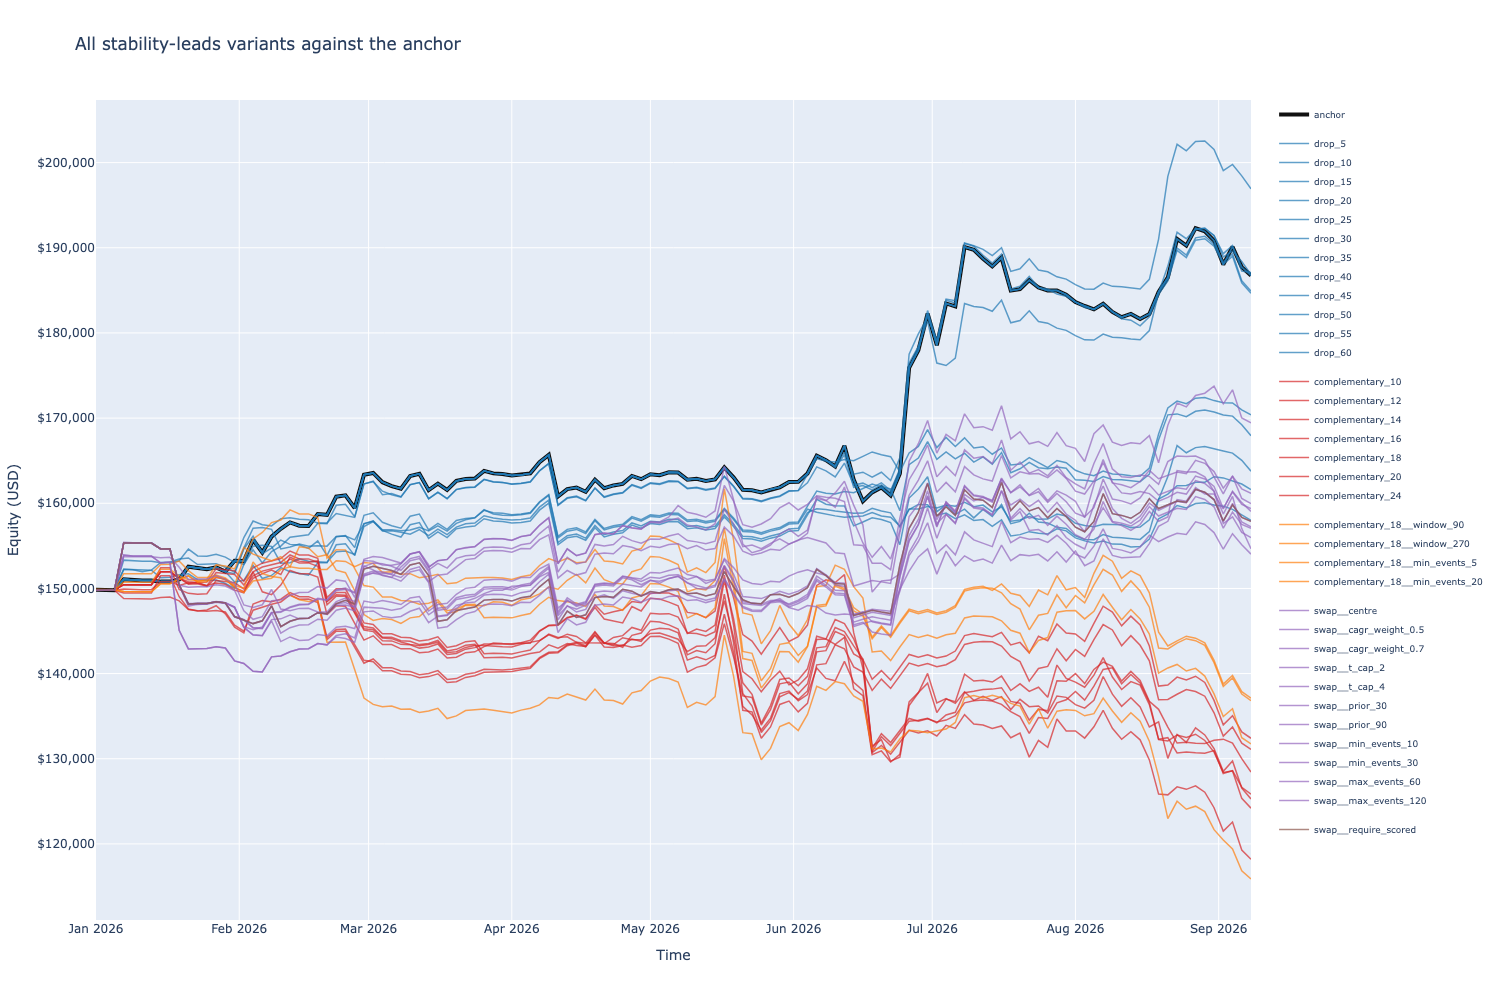

In [15]:
import plotly.graph_objects as go

FAMILY_COLOURS = {
    "anchor": "#111111",
    "NB21 data-availability drop": "#1f77b4",
    "NB22 joint downside": "#d62728",
    "NB22 window sensitivity": "#ff7f0e",
    "NB23 Sortino leg swap": "#9467bd",
    "NB23 policy": "#8c564b",
}

def equity_figure(labels, title, log_y=False):
    fig = go.Figure()
    for label in labels:
        curve = equity_by_label[label]
        is_anchor = label == "anchor"
        fig.add_trace(go.Scatter(
            x=curve.index, y=curve.to_numpy(), name=label, mode="lines",
            line=dict(color=FAMILY_COLOURS.get(family_by_label[label], "#888888"),
                      width=4 if is_anchor else 1.5),
            opacity=1.0 if is_anchor else 0.7,
            legendgroup=family_by_label[label],
            hovertemplate="%{fullData.name}<br>%{x|%Y-%m-%d}<br>$%{y:,.0f}<extra></extra>",
        ))
    fig.update_layout(title=title, hovermode="x unified", legend=dict(font=dict(size=9)))
    fig.update_yaxes(title="Equity (USD)", tickformat="$,.0f", type="log" if log_y else "linear")
    fig.update_xaxes(title="Time")
    return fig


equity_figure(list(equity_by_label), "All stability-leads variants against the anchor").show()


## One family at a time

The combined chart is crowded by design - the spread is the point. These separate the families so
each can be read against the anchor on its own.


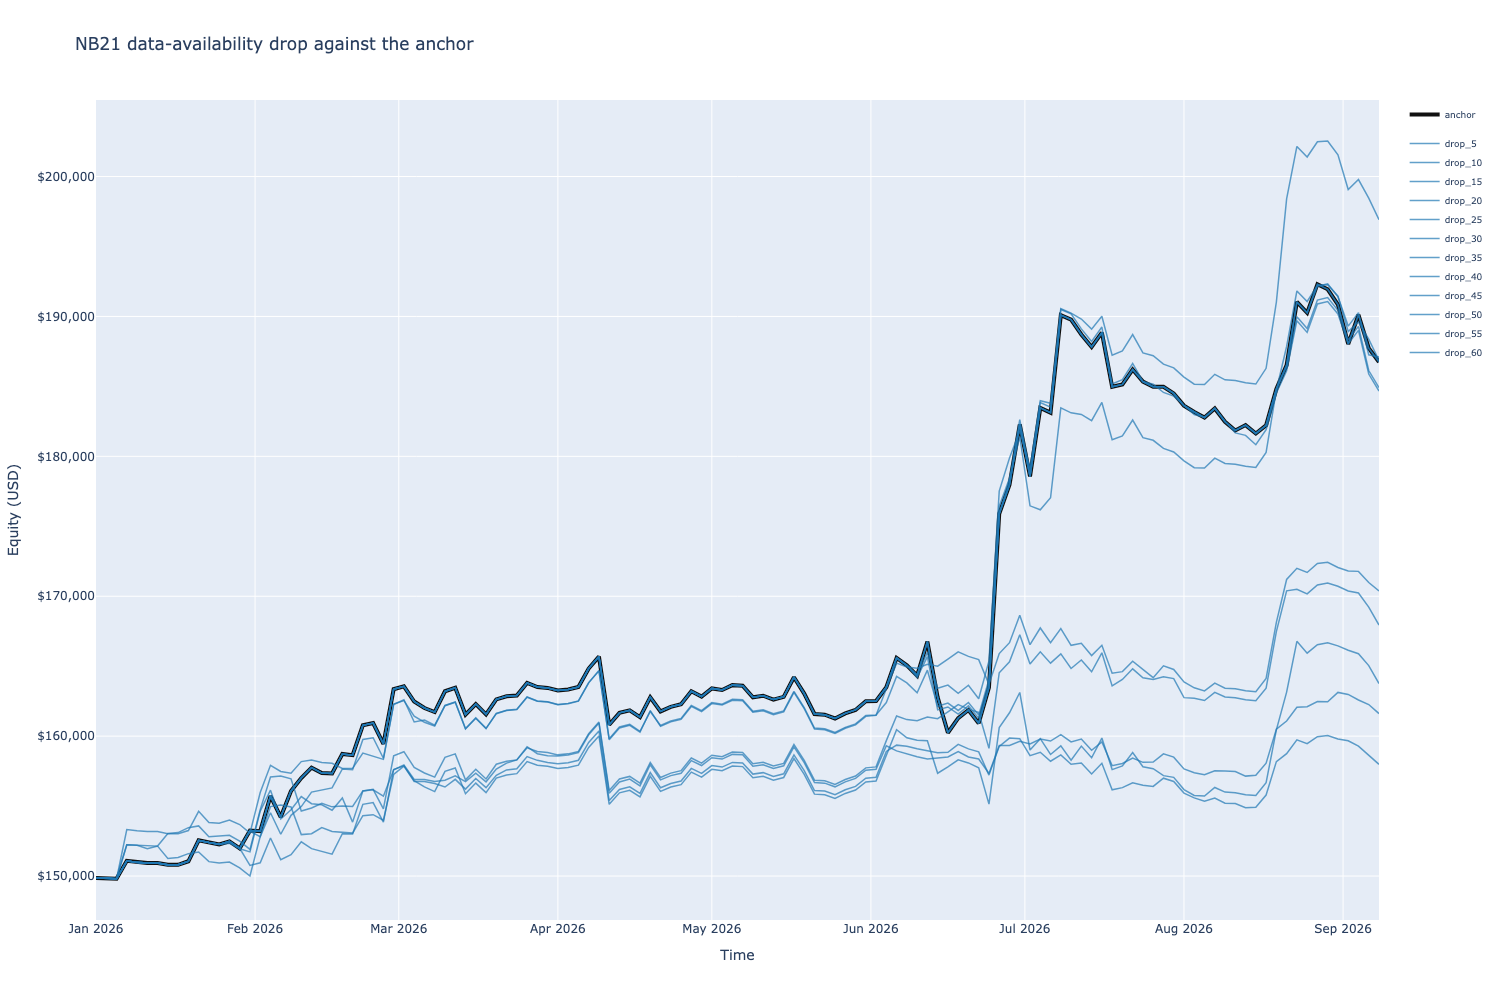

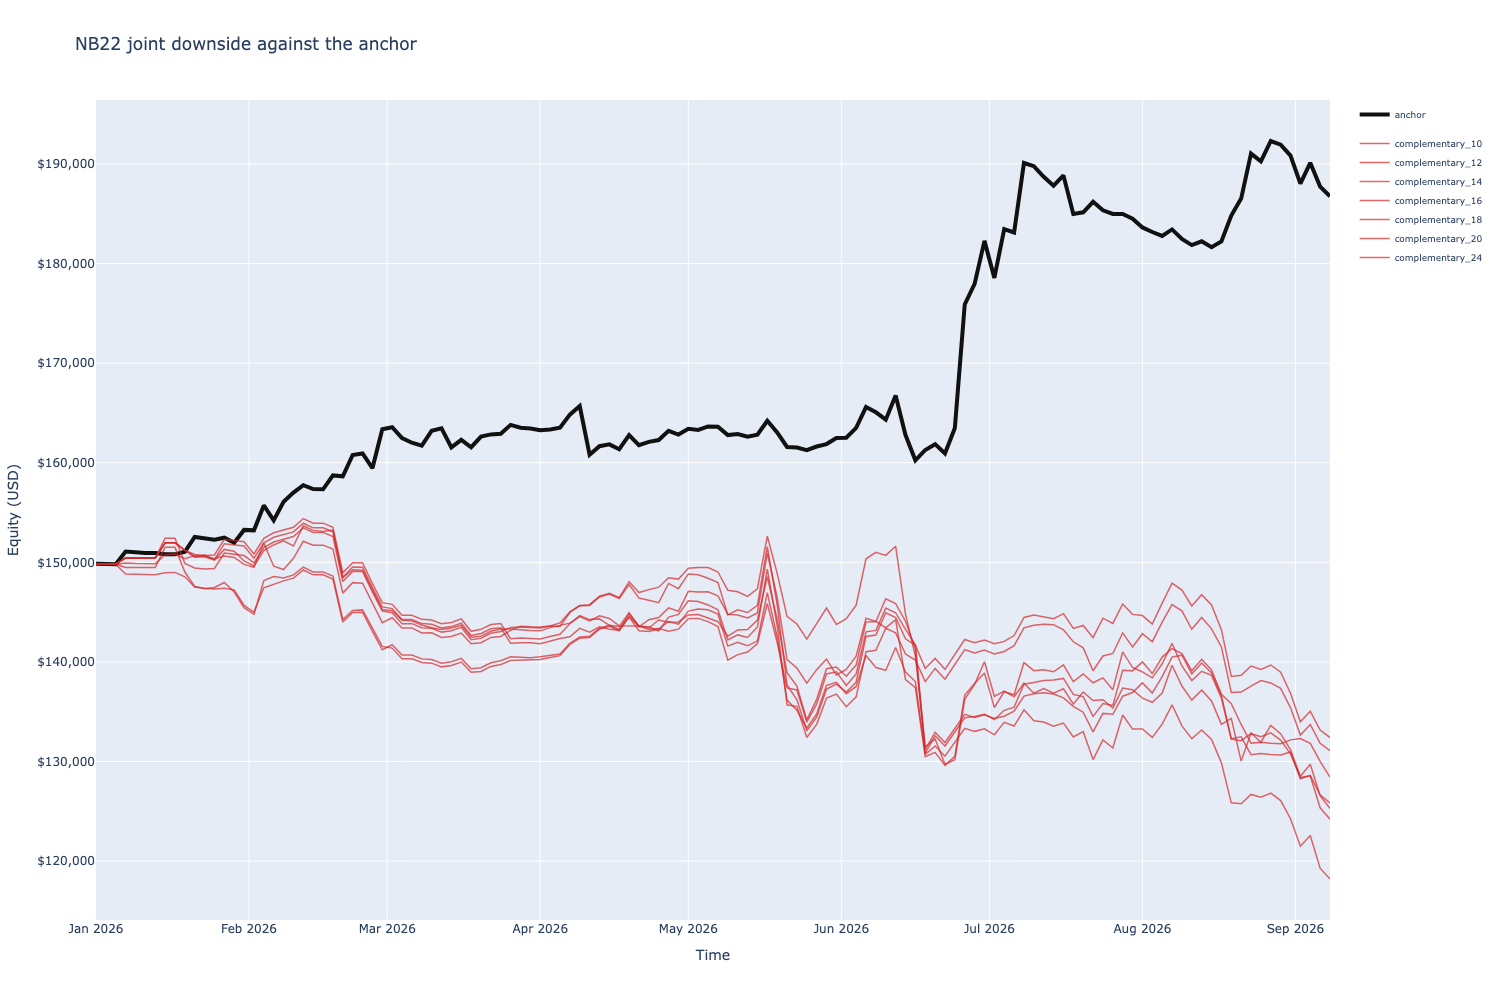

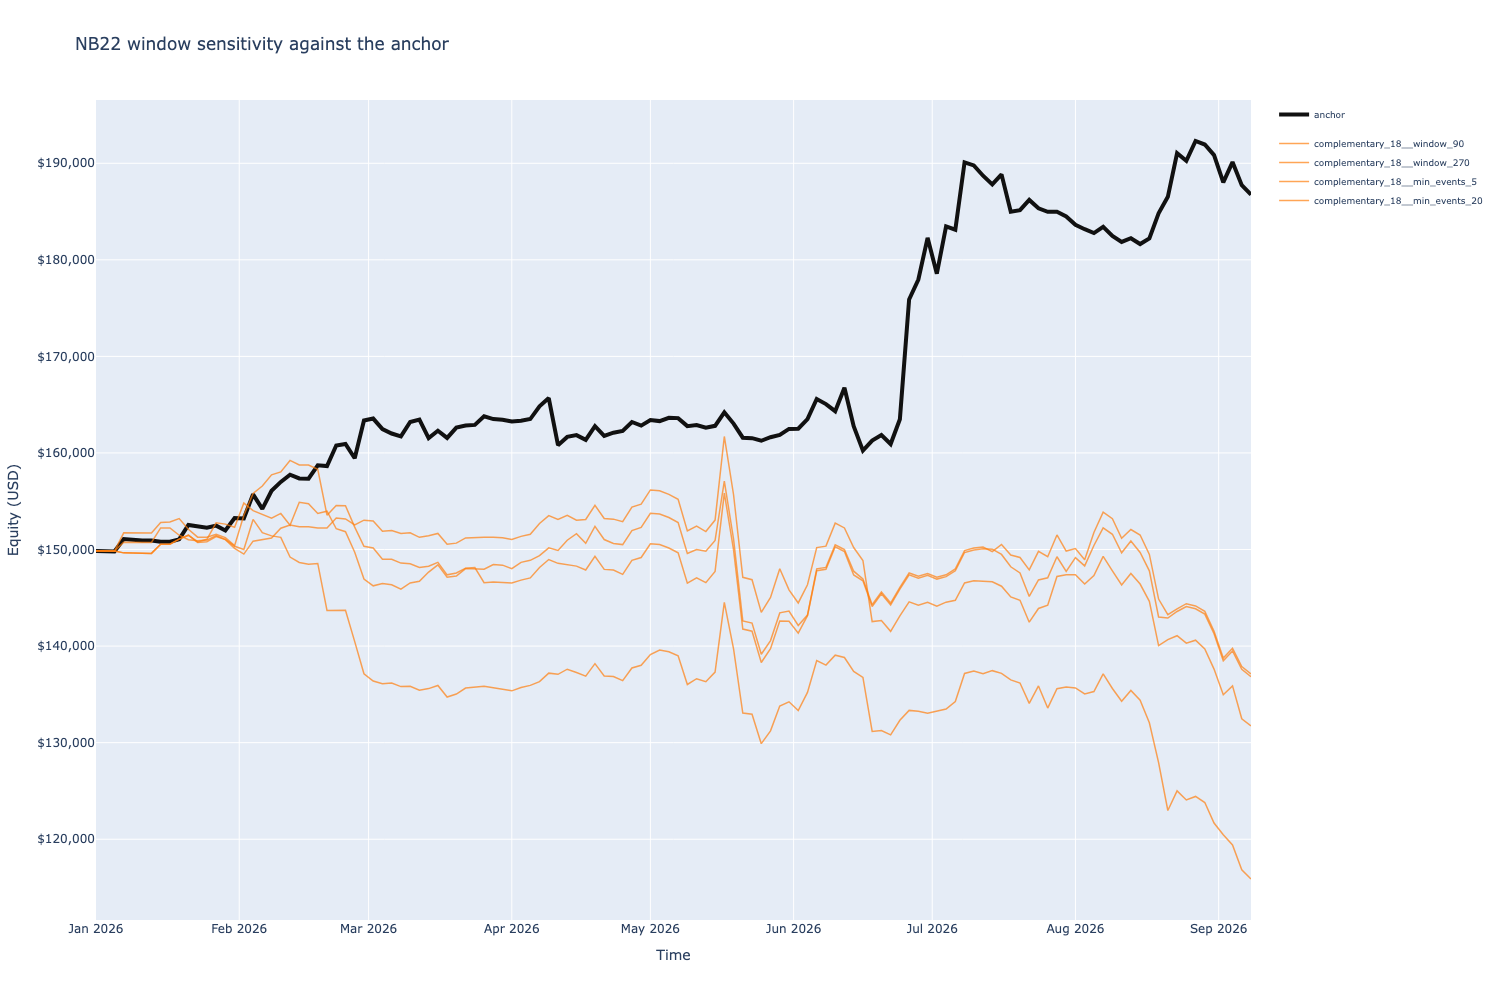

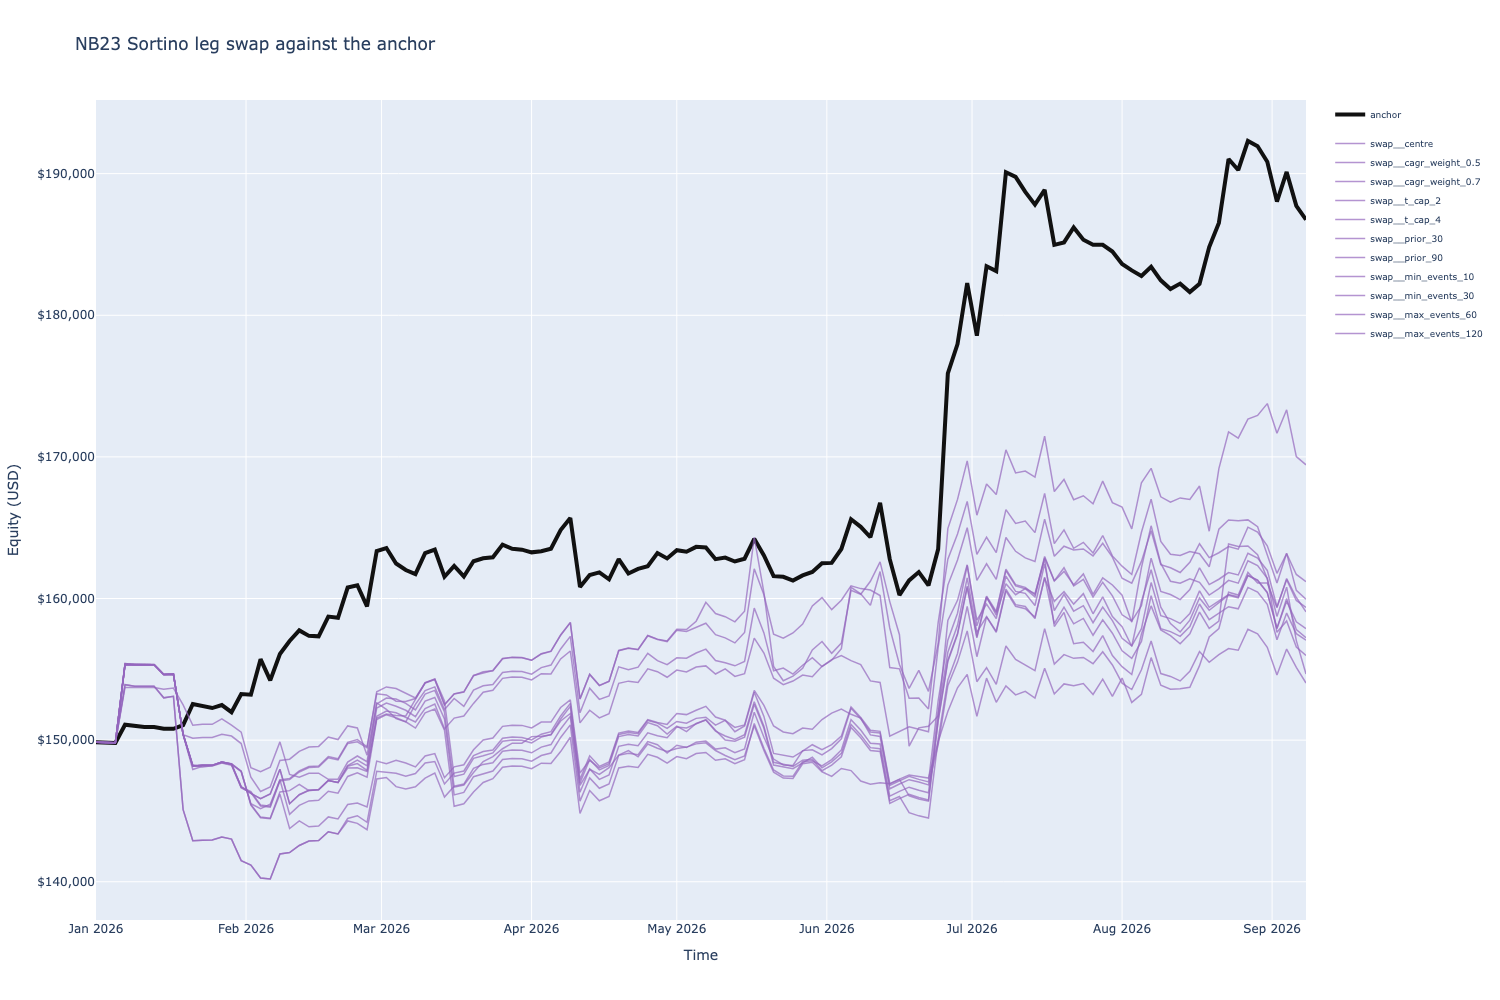

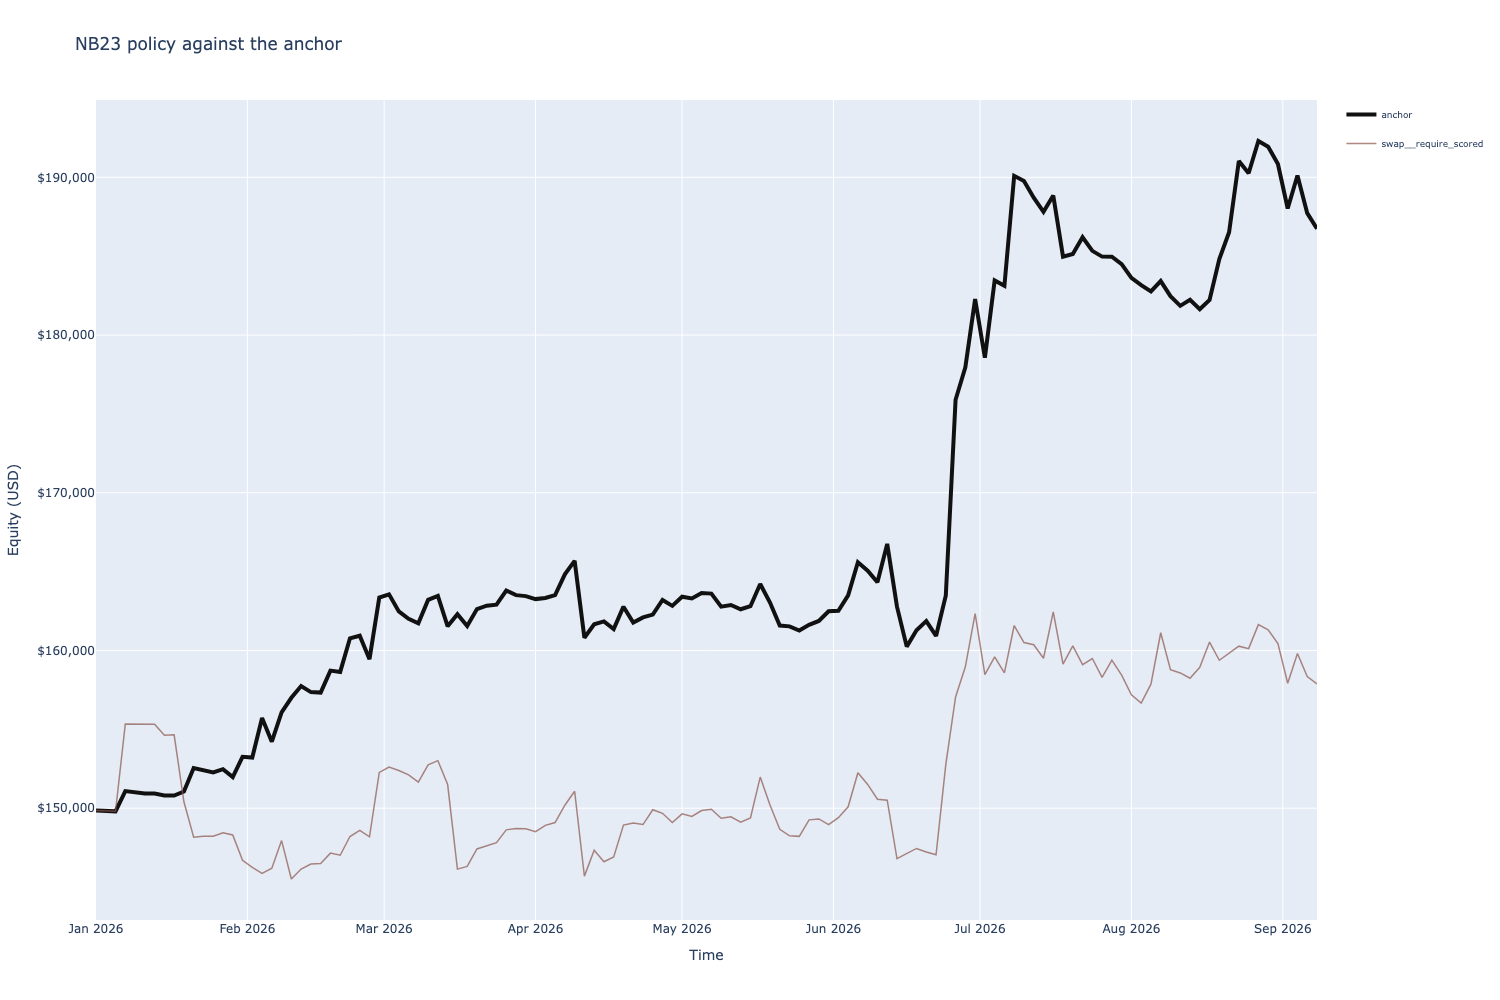

In [16]:
for name in ["NB21 data-availability drop", "NB22 joint downside",
             "NB22 window sensitivity", "NB23 Sortino leg swap", "NB23 policy"]:
    labels = ["anchor"] + [l for l, f in family_by_label.items() if f == name]
    equity_figure(labels, f"{name} against the anchor").show()


# Underwater curves

Drawdown from each run's own running peak. This is the shape the plan was trying to improve, and
the ulcer index in the table above is the root-mean-square of these depths.

Read these against NB20: a vault whose mark goes stale contributes a flat line rather than a real
recovery, and dropping the eleven cycles where most of the invested book was stale moves the
ANCHOR'S ulcer by 4.4%. That sensitivity was measured on the anchor alone. It never measured a
candidate-minus-anchor difference, so it is not an error bar on any curve here and not a
distinguishability threshold between two curves. It is context, and the honest use of it is as a
rough sense of scale: a gap of that order between two of these curves is small enough that
reporting behaviour is a live alternative explanation for it.


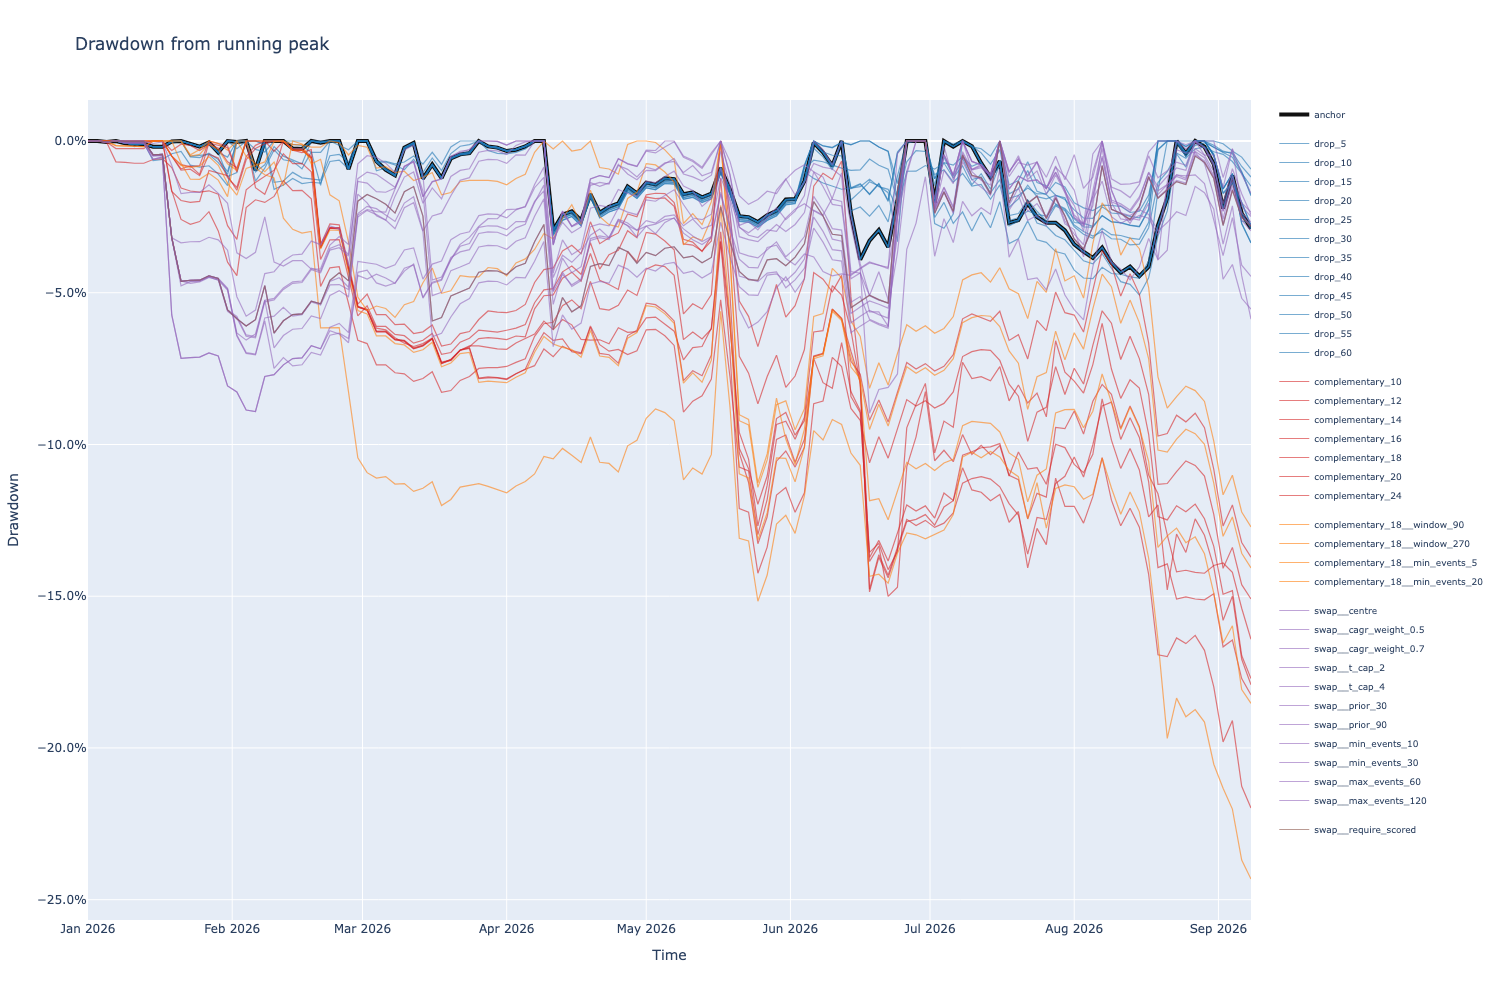

In [17]:
fig = go.Figure()
for label, curve in equity_by_label.items():
    drawdown = curve / curve.cummax() - 1.0
    is_anchor = label == "anchor"
    fig.add_trace(go.Scatter(
        x=drawdown.index, y=drawdown.to_numpy(), name=label, mode="lines",
        line=dict(color=FAMILY_COLOURS.get(family_by_label[label], "#888888"),
                  width=4 if is_anchor else 1.2),
        opacity=1.0 if is_anchor else 0.6,
        legendgroup=family_by_label[label],
        hovertemplate="%{fullData.name}<br>%{x|%Y-%m-%d}<br>%{y:.2%}<extra></extra>",
    ))
fig.update_layout(title="Drawdown from running peak", hovermode="x unified",
                  legend=dict(font=dict(size=9)))
fig.update_yaxes(title="Drawdown", tickformat=".1%")
fig.update_xaxes(title="Time")
fig.show()


# The trade-off the plan is actually about

Return against smoothness. Up and to the left is better: higher CAGR, lower ulcer index. The
dashed lines are the anchor's position, so the top-left quadrant beats it on both axes at once.
Marker size is invested-basket BTC beta, the plan's second risk goal, so a small marker in the
top-left quadrant is what the plan was looking for.

The printed list below applies the quadrant as a STRICT arithmetic predicate, and strict
arithmetic is all it establishes. The margin columns are there because two of the runs it returns
win by amounts far below anything this notebook can interpret: read the deltas, not the row count.


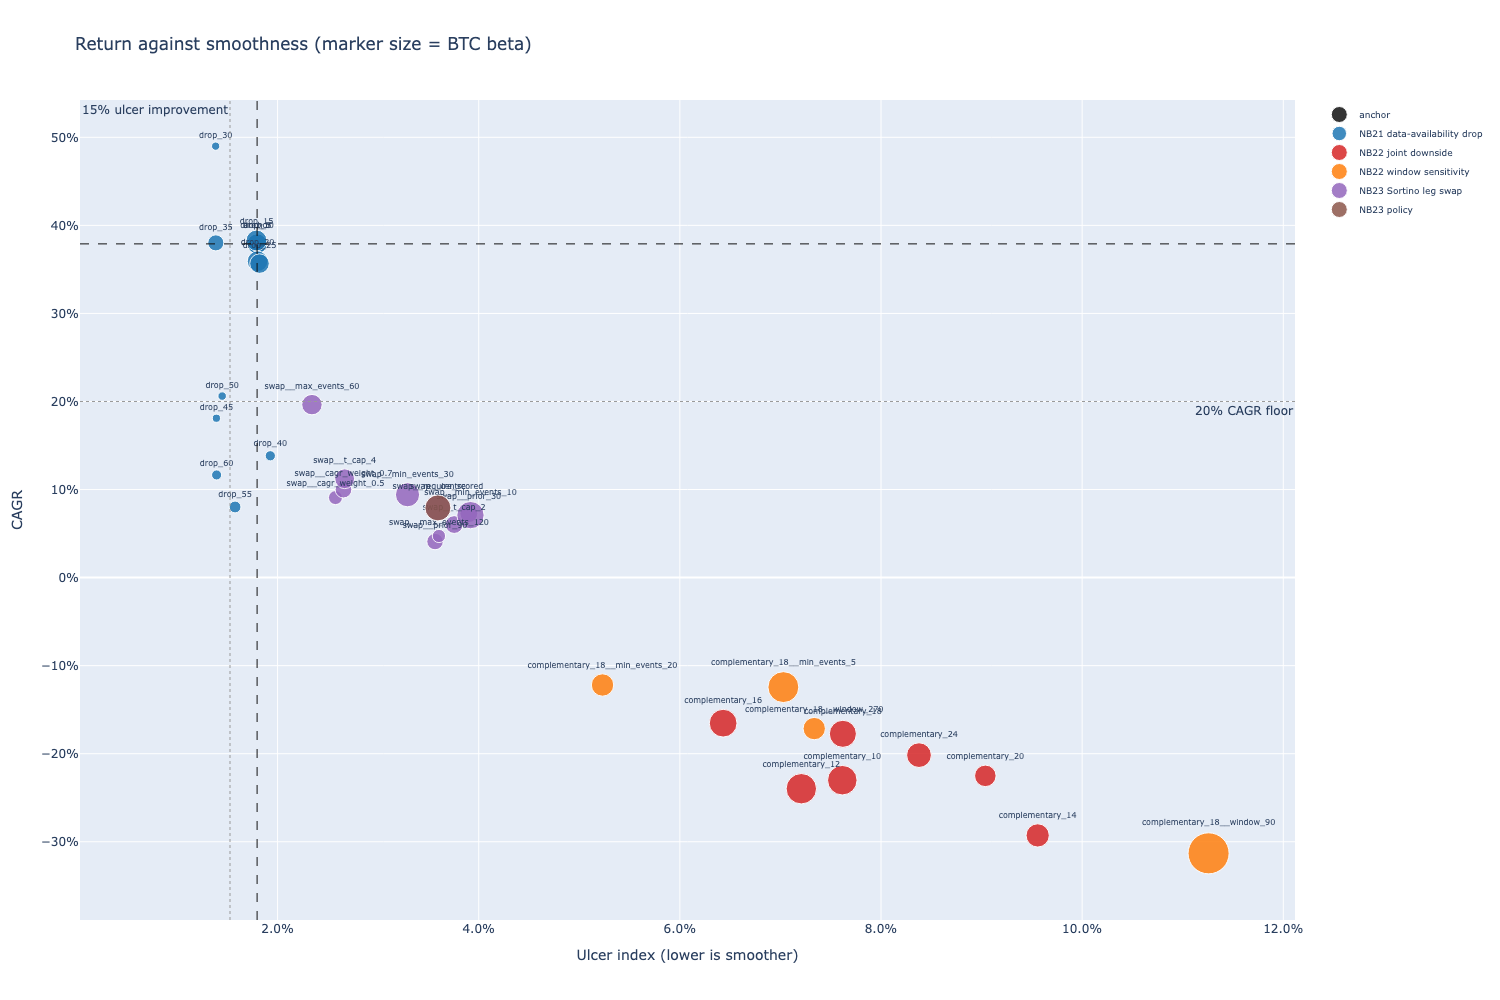

Runs meeting the strict predicate (CAGR above AND ulcer below the anchor's):


,family,cagr,cagr_vs_anchor,ulcer,ulcer_vs_anchor_rel,martin,abs_invested_beta,late_ok,passes_v3,failed
label,,,,,,,,,,
drop_10,NB21 data-availability drop,0.379048,0.000077,0.017964,-0.000026,21.100835,0.045804,True,False,"ulcer (not material), beta, observed control"
drop_15,NB21 data-availability drop,0.382814,0.003844,0.017905,-0.003315,21.380842,0.049494,True,False,"ulcer (not material), beta, observed control"
drop_30,NB21 data-availability drop,0.489942,0.110971,0.013843,-0.229401,35.392444,0.001055,True,False,observed control
drop_35,NB21 data-availability drop,0.380117,0.001147,0.013860,-0.228449,27.425051,0.031071,True,False,observed control


In [18]:
plot_df = comparison.reset_index()

fig = go.Figure()
for name in plot_df["family"].unique():
    subset = plot_df[plot_df["family"] == name]
    fig.add_trace(go.Scatter(
        x=subset["ulcer"], y=subset["cagr"], mode="markers+text",
        name=name, text=subset["label"], textposition="top center", textfont=dict(size=8),
        marker=dict(size=8 + 260 * subset["abs_invested_beta"],
                    color=FAMILY_COLOURS.get(name, "#888888"),
                    line=dict(width=1, color="white"), opacity=0.85),
        hovertemplate=("%{text}<br>CAGR %{y:.2%}<br>Ulcer %{x:.2%}"
                       "<br>Beta %{customdata:.4f}<extra></extra>"),
        customdata=subset["abs_invested_beta"],
    ))

fig.add_hline(y=float(anchor_panel["cagr"]), line=dict(dash="dash", color="#111111", width=1))
fig.add_vline(x=float(anchor_panel["ulcer"]), line=dict(dash="dash", color="#111111", width=1))
fig.add_hline(y=CAGR_FLOOR_V2, line=dict(dash="dot", color="#999999", width=1),
              annotation_text="20% CAGR floor", annotation_position="bottom right")
fig.add_vline(x=float(anchor_panel["ulcer"]) * (1.0 - ULCER_IMPROVEMENT_FRAC),
              line=dict(dash="dot", color="#999999", width=1),
              annotation_text="15% ulcer improvement", annotation_position="top left")
fig.update_layout(title="Return against smoothness (marker size = BTC beta)",
                  legend=dict(font=dict(size=9)))
fig.update_yaxes(title="CAGR", tickformat=".0%")
fig.update_xaxes(title="Ulcer index (lower is smoother)", tickformat=".1%")
fig.show()

better_both = comparison[
    (comparison["cagr"] > anchor_panel["cagr"]) & (comparison["ulcer"] < anchor_panel["ulcer"])
].copy()
better_both["cagr_vs_anchor"] = better_both["cagr"] - anchor_panel["cagr"]
better_both["ulcer_vs_anchor_rel"] = better_both["ulcer"] / anchor_panel["ulcer"] - 1.0
print("Runs meeting the strict predicate (CAGR above AND ulcer below the anchor's):")
display(better_both[["family", "cagr", "cagr_vs_anchor", "ulcer", "ulcer_vs_anchor_rel",
                     "martin", "abs_invested_beta", "late_ok", "passes_v3", "failed"]]
        if len(better_both) else "  none")


# Sharpe against volatility, with the observed-control bar

Constraint 7 compares a candidate against the BEST observed control no noisier than it is, so as
a function of volatility the reference is the running maximum of the drop family's Sharpe, not
the family's own profile. It can never fall as volatility rises, whereas the family's profile
falls repeatedly. Joining the twelve family points and calling that the bar would understate it
across the whole 14.9% to 15.4% band where most of the runs sit, so the family is drawn as points
and the bar is drawn separately: the running maximum, plus the 0.10 margin, as a step.

Which member sets the bar is in the `c7_reference` column of the table above (cell 24): `drop_30`
for 25 of the 36 rows, `drop_50` for six, `drop_35` for three and `drop_60` for two.


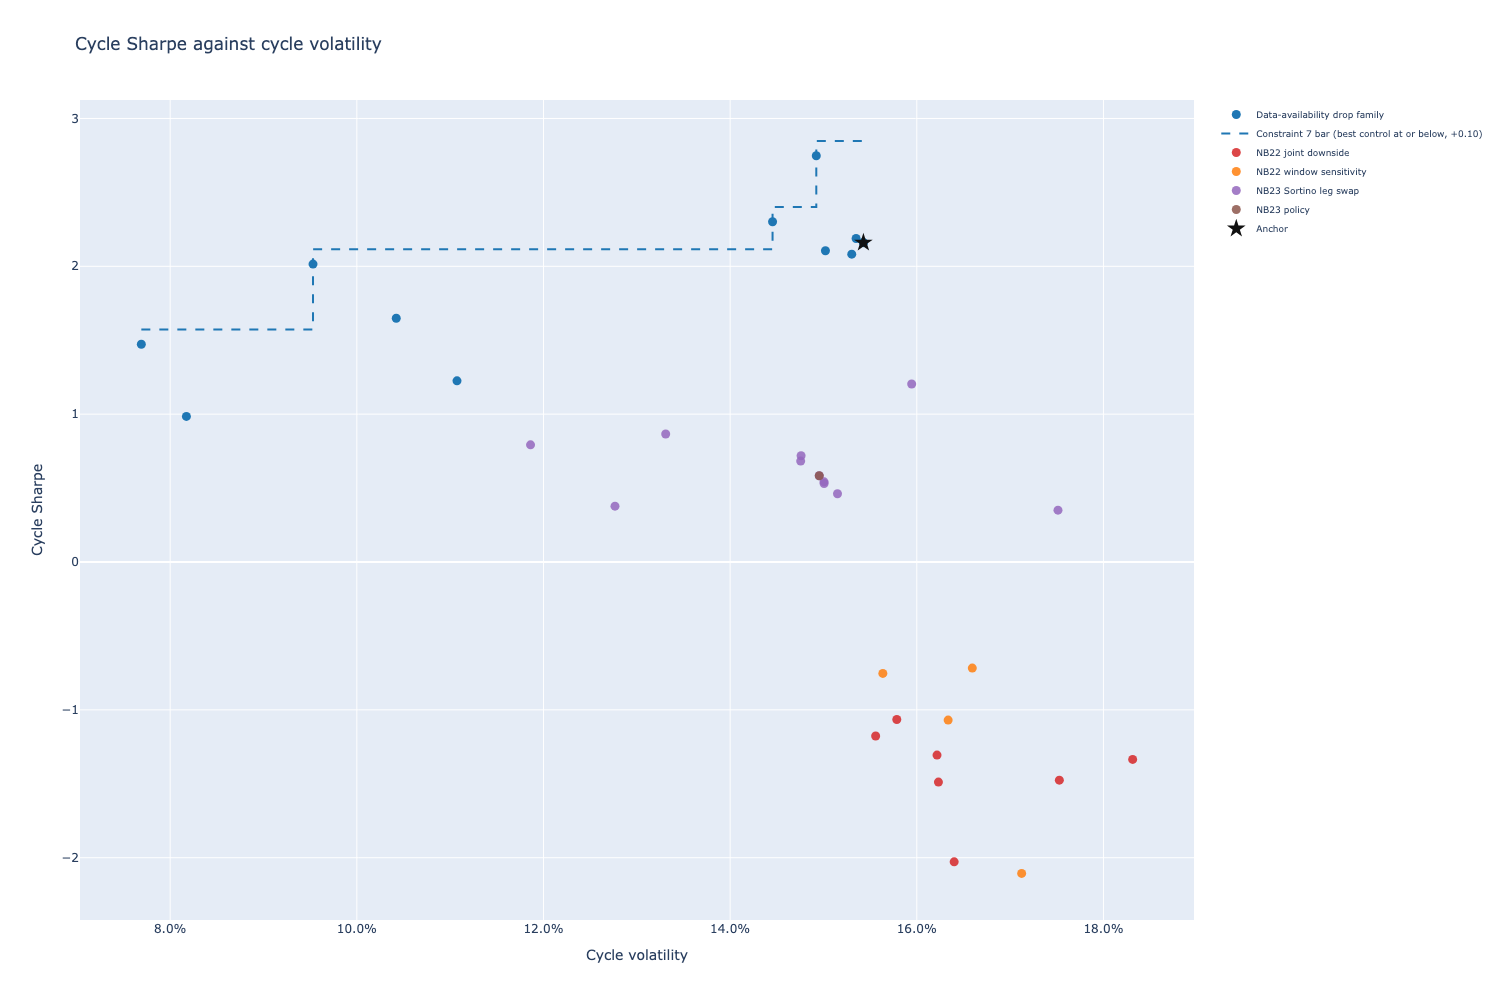

In [19]:
frontier = family.sort_values("cycle_vol")
#: `placebo_ref_observed()` takes the maximum Sharpe among members at or below the candidate's
#: volatility, so the reference as a function of volatility is the RUNNING maximum - a
#: non-decreasing step. The polyline through the family points is not the bar and is not drawn as
#: one; a step at `cummax` + the margin is.
constraint_7_bar = frontier["cycle_sharpe"].cummax() + PLACEBO_MARGIN_V3

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=frontier["cycle_vol"], y=frontier["cycle_sharpe"], mode="markers",
    name="Data-availability drop family", marker=dict(color="#1f77b4", size=9),
    text=[f"drop {int(n)}" for n in frontier["drop_n"]],
    hovertemplate="%{text}<br>vol %{x:.2%}<br>Sharpe %{y:.3f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=frontier["cycle_vol"], y=constraint_7_bar, mode="lines",
    name="Constraint 7 bar (best control at or below, +0.10)",
    line=dict(color="#1f77b4", dash="dash", shape="hv"),
    hovertemplate="bar %{y:.3f} at vol %{x:.2%}<extra></extra>",
))
for name in ("NB22 joint downside", "NB22 window sensitivity",
             "NB23 Sortino leg swap", "NB23 policy"):
    subset = comparison[comparison["family"] == name]
    fig.add_trace(go.Scatter(
        x=subset["cycle_vol"], y=subset["cycle_sharpe"], mode="markers", name=name,
        marker=dict(size=9, color=FAMILY_COLOURS.get(name, "#888888"), opacity=0.85),
        text=subset.index, hovertemplate="%{text}<br>vol %{x:.2%}<br>Sharpe %{y:.3f}<extra></extra>",
    ))
fig.add_trace(go.Scatter(
    x=[anchor_panel["cycle_vol"]], y=[anchor_panel["cycle_sharpe"]], mode="markers",
    name="Anchor", marker=dict(color="#111111", size=14, symbol="star"),
))
fig.update_layout(title="Cycle Sharpe against cycle volatility", legend=dict(font=dict(size=9)))
fig.update_yaxes(title="Cycle Sharpe")
fig.update_xaxes(title="Cycle volatility", tickformat=".1%")
fig.show()


# How each family fails

One row per family: how many runs it contains, how many pass all seven constraints, and which
constraint binds most often. The plan's question was whether the families fail in the same way or
in different ways.

`every failure seen` is the whole inventory, never truncated, and it is the column to read.
`most common failure` is a single mode and on this data it is usually `observed control`, which
is the uniformly applied constraint 7 rather than an informative result - the drop family's x12
is twelve self-comparisons. One constraint is absent from every row: no run breaches the 90%
deployment floor, and no run was disqualified for a non-finite metric.


In [20]:
from collections import Counter

rows = []
for name, group in comparison.groupby("family"):
    counter = Counter()
    for failed in group["failed"]:
        for constraint in (c.strip() for c in failed.split(",") if c.strip()):
            counter[constraint] += 1
    rows.append({
        "family": name,
        "runs": len(group),
        "passing all seven": int(group["passes_v3"].sum()),
        "late period holds": int(group["late_ok"].sum()),
        "median CAGR": group["cagr"].median(),
        "median ulcer": group["ulcer"].median(),
        "most common failure": counter.most_common(1)[0][0] if counter else "none",
        "how often": counter.most_common(1)[0][1] if counter else 0,
        "every failure seen": "; ".join(f"{c} x{n}" for c, n in counter.most_common()),
    })
display(pd.DataFrame(rows).set_index("family"))


,runs,passing all seven,late period holds,median CAGR,median ulcer,most common failure,how often,every failure seen
family,,,,,,,,
NB21 data-availability drop,12,0,8,0.357913,0.016839,observed control,12,observed control x12; ulcer (not material) x7; Sharpe non-inferiority x5; beta x4; CAGR < 20% x4
NB22 joint downside,7,0,0,-0.225132,0.076208,CAGR < 20%,7,CAGR < 20% x7; Sharpe non-inferiority x7; volatility x7; ulcer (not material) x7; beta x7; observed control x7
NB22 window sensitivity,4,0,0,-0.147904,0.071827,CAGR < 20%,4,CAGR < 20% x4; Sharpe non-inferiority x4; volatility x4; ulcer (not material) x4; beta x4; observed control x4
NB23 Sortino leg swap,11,0,4,0.079145,0.035657,CAGR < 20%,11,CAGR < 20% x11; Sharpe non-inferiority x11; ulcer (not material) x11; observed control x11; beta x4; volatility x2
NB23 policy,1,0,0,0.079145,0.035943,CAGR < 20%,1,CAGR < 20% x1; Sharpe non-inferiority x1; ulcer (not material) x1; beta x1; observed control x1
anchor,1,0,0,0.378971,0.017964,ulcer (not material),1,ulcer (not material) x1; beta x1; observed control x1
